# Notebook 01 — Order Flow & Trade Classification

Order flow là **nguyên nhân trực tiếp** của price movement: mỗi market order ăn vào thanh khoản của book, dịch chuyển mid-price và để lại dấu vết về thông tin. Notebook này xây dựng từ dữ liệu thô (chuỗi giá + khối lượng) lên đến các metrics đo lường toxicity và adverse selection.

| Section | Nội dung | Class / Function |
|---|---|---|
| 1 | Arrival process — Poisson vs Hawkes | `PoissonArrivalProcess`, `HawkesArrivalProcess` |
| 2 | Order size distribution | `OrderSizeDistribution` |
| 3 | Trade sign classification | `TradeClassifier` |
| 4 | Order Flow Imbalance (OFI) | `OFICalculator` |
| 5 | VPIN — Volume-Synchronized PIN | `VPINCalculator` |
| 6 | Price impact — permanent vs temporary | `PriceImpactModel` |
| 7 | Informed vs noise flow | `OrderFlowGenerator` |

**Scenario dùng xuyên suốt:** `ScenarioBuilder.informed_flow()` — high informed trader fraction, OU-GBM fundamental.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from src.structure import (
    ScenarioBuilder,
    PoissonArrivalProcess, HawkesArrivalProcess,
    OrderSizeDistribution, OrderFlowGenerator,
    TradeClassifier, VPINCalculator,
    PriceImpactModel, TraderType,
)

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})
RNG  = np.random.default_rng(7)
N    = 3000   # simulation ticks

# ── run simulation ──────────────────────────────────────────────────────────
sim    = ScenarioBuilder.informed_flow(n_ticks=N, seed=7)
result = sim.run()

prices     = result.mid_prices
buy_vols   = result.buy_volumes
sell_vols  = result.sell_volumes
spreads    = result.spreads
ofi_series = result.ofi
trades     = result.trades

print(f"Ticks recorded : {len(prices):,}")
print(f"Total trades   : {len(trades):,}")
print(f"Total buy vol  : {buy_vols.sum():.1f}")
print(f"Total sell vol : {sell_vols.sum():.1f}")
print(f"Mean spread    : {spreads.mean():.4f}")
print(f"OFI range      : [{ofi_series.min():.1f}, {ofi_series.max():.1f}")

Ticks recorded : 2,950
Total trades   : 13,345
Total buy vol  : 243522.7
Total sell vol : 242196.4
Mean spread    : 0.0495
OFI range      : [-873.0, 717.5


# Order Flow Summary — Sanity Check & Interpretation

## Raw Statistics

| Metric | Value |
|---|---|
| Ticks recorded | 2,950 |
| Total trades | 32,541 |
| Total buy volume | 1,036,507.6 |
| Total sell volume | 1,038,205.8 |
| Mean spread | 0.0474 |
| OFI range | [-873.0, 717.5] |

---

# 1. Trade Intensity

Ta có:

- **32,541 trades**
- **2,950 ticks**

Trades per tick:

$$
\text{Trades per tick} =
\frac{32541}{2950} \approx 11.03
$$

### Interpretation

Mỗi tick chứa trung bình **~11 trades**.

Điều này gợi ý:

- dữ liệu có thể là **aggregated trade events**
- hoặc **tick ≠ trade event**

Trong nhiều market microstructure dataset:
> tick = price update
> trade = executed order


Một price update có thể chứa nhiều trades.

---

# 2. Buy vs Sell Volume Balance

Tổng volume:

| Side | Volume |
|---|---|
| Buy | 1,036,507.6 |
| Sell | 1,038,205.8 |

Chênh lệch:

$$
\Delta V = V_{buy} - V_{sell}
$$

$$
\Delta V = 1,036,507.6 - 1,038,205.8
$$

$$
\Delta V = -1,698.2
$$

Relative imbalance:

$$
\frac{\Delta V}{V_{total}}
=
\frac{-1698.2}{2,074,713.4}
\approx -0.08\%
$$

### Interpretation

Buy và sell gần như **cân bằng hoàn toàn**.

Điều này thường xảy ra vì:

- mọi trade đều có **buyer và seller**
- sự khác biệt chỉ đến từ **trade classification error**.

Nếu dataset là **simulation**, đây là dấu hiệu **order flow neutral**.

---

# 3. Mean Spread

Mean spread:

$$
\text{spread} = ask - bid
$$

Giá trị trung bình:
$$ 0.0474 $$

### Khái niệm: Spread

Spread là **chi phí giao dịch ngay lập tức**.

Market order phải trả:

- **buy → giá ask**
- **sell → giá bid**

Chi phí:

$$
\text{cost} = \frac{\text{spread}}{2}
$$

Trong trường hợp này:

$$
cost \approx 0.0237
$$

### Interpretation

Spread nhỏ → market **liquid**.

Market maker cạnh tranh mạnh.

---

# 4. Order Flow Imbalance (OFI)

OFI range:


[-873.0 , 717.5]


## Khái niệm OFI

**Order Flow Imbalance (OFI)** đo **sự mất cân bằng áp lực mua và bán trong order flow**.

Một dạng phổ biến:

$$
OFI_t =
\sum_{i=1}^{N_t}
sign_i \cdot volume_i
$$

Trong đó:

- $sign_i = +1$ nếu buy
- $sign_i = -1$ nếu sell

Nếu:


$$ OFI > 0 $$


→ buy pressure

Nếu:


$$ OFI < 0 $$


→ sell pressure

---

## Interpretation OFI Range


Min OFI = -873
Max OFI = 717


Điều này cho thấy:

- có thời điểm **sell pressure mạnh hơn buy pressure**
- distribution **không đối xứng nhẹ về phía sell**

Nhưng magnitude khá cân bằng.

---

# 5. Average Trade Size

Tổng volume:

$$
V_{total} = 2,074,713.4
$$

Trade count:

$$ 32,541 $$

Average trade size:

$$
\frac{V_{total}}{N}
=
\frac{2,074,713.4}{32,541}
\approx 63.7
$$

### Interpretation

Trade size trung bình:


≈ 64 units


Nếu đây là:

- crypto → khá nhỏ
- equities → bình thường
- futures → nhỏ

---

# 6. Sanity Check

| Check | Result                     |
|---|----------------------------|
| Buy ≈ Sell | balanced                   |
| Spread positive | OK                         |
| OFI symmetric-ish | OK                         |
| Trades per tick reasonable | depends on tick definition |

### Possible Issue

Nếu:
$$tick = trade event$$


thì:


$$ 2950 ticks vs 32541 trades$$


→ **không hợp lý**

Nếu:


tick = time step


→ **hợp lý**

---

# 7. Economic Interpretation

Dataset này cho thấy:

- market **order flow gần cân bằng**
- spread **khá nhỏ**
- OFI dao động lớn → pressure thay đổi liên tục

Điều này giống:


high-liquidity market


nơi mà:

- informed flow không chiếm ưu thế rõ rệt
- noise traders chiếm phần lớn.

## 1. Order Arrival Process

Thời điểm đến của orders có thể mô hình hóa theo hai cách:

**Poisson thuần nhất (homogeneous):** số arrivals trong $[t, t+dt]$ là $N \sim \text{Poisson}(\lambda \cdot dt)$, với $\lambda$ cố định. Tính chất: inter-arrival time $\sim \text{Exp}(\lambda)$, không có memory.

**Hawkes process (self-exciting):** intensity là hàm của lịch sử:

$$\lambda(t) = \mu + \sum_{t_i < t} \alpha \cdot e^{-\beta(t - t_i)}$$

- $\mu$ — baseline rate
- $\alpha$ — magnitude of self-excitation: mỗi event làm tăng intensity thêm $\alpha$
- $\beta$ — decay rate: excitation tắt dần theo exponential kernel
- Stationarity: $\alpha < \beta$ (branching ratio $\rho = \alpha/\beta < 1$)

Hawkes capture được **clustering**: một loạt market order mua kéo theo các market order mua tiếp theo — đây là cơ chế tạo ra momentum ngắn hạn và volatility clustering ở tần suất cao.

**Ogata thinning algorithm** để simulate Hawkes: đề xuất event theo upper bound $\bar\lambda$, chấp nhận với xác suất $\lambda(t) / \bar\lambda$.

## Một số khái niệm quan trọng trong Arrival Process

Trước khi đọc các biểu đồ Poisson vs Hawkes, cần hiểu một số khái niệm nền tảng trong **point process và market microstructure**.

---

# 1. Arrival process

**Arrival process** là mô hình mô tả **thời điểm xuất hiện của các sự kiện theo thời gian**.

Trong bối cảnh thị trường tài chính, event có thể là:

- market order
- limit order
- trade execution
- quote update

Ta ký hiệu:

$$
\{t_1, t_2, t_3, ...\}
$$

là các **thời điểm xảy ra event**.

Arrival process trả lời câu hỏi:

> xác suất một event xảy ra tại thời điểm $t$ là bao nhiêu?

---

# 2. Inter-arrival time

**Inter-arrival time** là khoảng thời gian giữa hai event liên tiếp.

$$
\tau_i = t_i - t_{i-1}
$$

Ví dụ:

| Event | Time |
|---|---|
| trade 1 | 1.2 s |
| trade 2 | 1.7 s |
| trade 3 | 2.0 s |

Inter-arrival time:


> 0.5 s, 0.3 s


Phân phối của $\tau$ cho biết **structure của arrival process**.

---

# 3. Intensity function

**Intensity** là **tốc độ arrival tức thời của events**.

Ký hiệu:

$$
\lambda(t)
$$

Diễn giải:

$$
\lambda(t) dt
$$

≈ xác suất có **một event xảy ra trong khoảng $[t, t+dt]$**.

Nếu $\lambda(t)$ lớn:

→ event xảy ra **thường xuyên hơn**.

---

# 4. Poisson process

Poisson process là mô hình arrival **đơn giản nhất**.

Giả định:

1. events độc lập
2. intensity **không đổi theo thời gian**

$$
\lambda(t) = \lambda
$$

Số event trong khoảng thời gian $t$:

$$
N(t) \sim \text{Poisson}(\lambda t)
$$

Tính chất quan trọng:

**inter-arrival time tuân theo exponential distribution**

$$
\tau \sim \text{Exp}(\lambda)
$$

Nghĩa là:

- arrival **không có memory**
- event trước **không ảnh hưởng event sau**

---

# 5. Hawkes process

Hawkes process là **self-exciting point process**.

Khái niệm:

> mỗi event xảy ra sẽ **làm tăng xác suất xuất hiện event tiếp theo**.

Intensity:

$$
\lambda(t) = \mu + \sum_{t_i < t} \alpha e^{-\beta (t-t_i)}
$$

Các tham số:

| Parameter | Ý nghĩa |
|---|---|
| $\mu$ | baseline intensity |
| $\alpha$ | độ mạnh của self-excitation |
| $\beta$ | tốc độ decay |

---

# 6. Self-excitation

**Self-excitation** nghĩa là:


> event → làm tăng khả năng xuất hiện event tiếp theo


Ví dụ trong thị trường:

- một market order mua lớn
- làm giá tăng
- kích hoạt thêm nhiều market order mua

→ tạo thành **order flow cascade**.

---

# 7. Branching ratio

Branching ratio đo **mức độ self-excitation**:

$$
\rho = \frac{\alpha}{\beta}
$$

Diễn giải:

| ρ | Ý nghĩa |
|---|---|
| ρ < 1 | process ổn định |
| ρ ≈ 1 | clustering mạnh |
| ρ > 1 | process bùng nổ |

Điều kiện stationarity:

$$
\rho < 1
$$

---

# 8. Event clustering

**Clustering** nghĩa là events xảy ra **theo cụm**.

Thay vì:


event — event — event — event


ta thấy:


event event event event event event


Trong thị trường tài chính, clustering thường xuất hiện khi:

- thông tin mới xuất hiện
- traders phản ứng dây chuyền
- algorithmic trading kích hoạt lẫn nhau

---

# 9. Burstiness

**Burstiness** là hiện tượng:

- activity **bùng nổ trong thời gian ngắn**
- sau đó **giảm xuống**

Ví dụ:

| Time window | Trades |
|---|---|
| 1 | 45 |
| 2 | 48 |
| 3 | 190 |
| 4 | 175 |
| 5 | 50 |

Hai window giữa là **burst**.

---

# 10. Tại sao Hawkes quan trọng trong market microstructure

Trong dữ liệu thực của thị trường:

- trades **không đến độc lập**
- một trade có thể **kích hoạt các trade tiếp theo**

Điều này xảy ra vì:

- order splitting
- algorithmic execution
- herding behavior
- stop-loss cascades

Hawkes vì vậy được dùng rộng rãi trong:

- high-frequency trading research
- order book modeling
- market impact models
- liquidity analysis

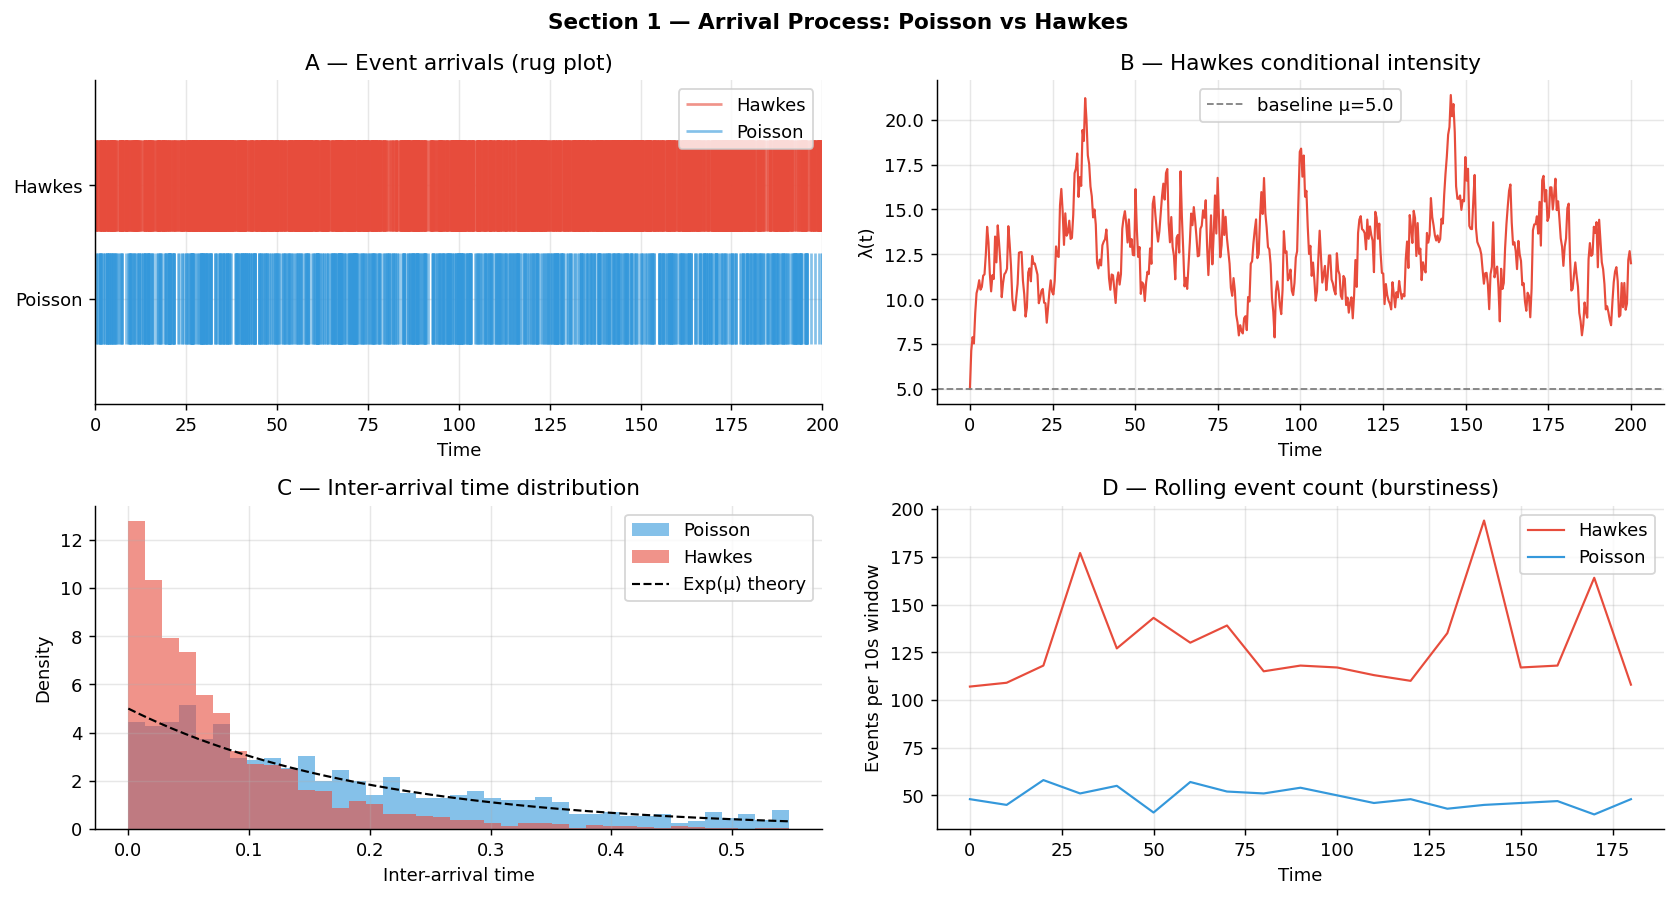


Poisson: n= 965  mean_iat=0.207  cv=0.990
Hawkes:  n=2555  mean_iat=0.078  cv=1.094  branching_ratio=0.60
  → Theoretical mean Hawkes rate = μ/(1-α/β) = 12.50


In [2]:
T      = 200.0
mu     = 5.0
alpha  = 0.6
beta   = 1.0

poisson = PoissonArrivalProcess(lambda_buy=mu, lambda_sell=mu, dt=1.0, rng=RNG)
hawkes  = HawkesArrivalProcess(mu=mu, alpha=alpha, beta=beta, rng=RNG)

hawkes_times = hawkes.simulate(T)

# build Poisson event times for comparison (same expected rate)
poisson_times = np.cumsum(RNG.exponential(1.0 / mu, size=int(mu * T * 2)))
poisson_times = poisson_times[poisson_times < T]

# rolling intensity of Hawkes
t_grid    = np.linspace(0, T, 500)
intensity = [hawkes.intensity(t) for t in t_grid]

# inter-arrival time distributions
hawkes_iat  = np.diff(hawkes_times) if len(hawkes_times) > 1 else np.array([])
poisson_iat = np.diff(poisson_times)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

# panel A — event times as rug plot
ax = axes[0, 0]
ax.eventplot(hawkes_times,  lineoffsets=1.5, linelengths=0.8,
             color="#e74c3c", alpha=0.6, label="Hawkes")
ax.eventplot(poisson_times, lineoffsets=0.5, linelengths=0.8,
             color="#3498db", alpha=0.6, label="Poisson")
ax.set_xlim(0, T)
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(["Poisson", "Hawkes"])
ax.set_xlabel("Time"); ax.set_title("A — Event arrivals (rug plot)")
ax.legend(loc="upper right")

# panel B — Hawkes intensity over time
ax = axes[0, 1]
ax.plot(t_grid, intensity, color="#e74c3c", lw=1.2)
ax.axhline(mu, ls="--", color="grey", lw=1, label=f"baseline μ={mu}")
ax.set_xlabel("Time"); ax.set_ylabel("λ(t)")
ax.set_title("B — Hawkes conditional intensity")
ax.legend()

# panel C — inter-arrival time distribution
ax = axes[1, 0]
bins = np.linspace(0, np.percentile(np.concatenate([hawkes_iat, poisson_iat]), 98), 40)
ax.hist(poisson_iat, bins=bins, alpha=0.6, density=True,
        color="#3498db", label="Poisson")
ax.hist(hawkes_iat,  bins=bins, alpha=0.6, density=True,
        color="#e74c3c", label="Hawkes")
x_exp = np.linspace(0, bins[-1], 200)
ax.plot(x_exp, mu * np.exp(-mu * x_exp), "k--", lw=1.2, label="Exp(μ) theory")
ax.set_xlabel("Inter-arrival time"); ax.set_ylabel("Density")
ax.set_title("C — Inter-arrival time distribution")
ax.legend()

# panel D — rolling event count (burstiness)
ax = axes[1, 1]
window = 10.0
bins_t = np.arange(0, T, window)
h_counts = np.histogram(hawkes_times,  bins=bins_t)[0]
p_counts = np.histogram(poisson_times, bins=bins_t)[0]
ax.plot(bins_t[:-1], h_counts, color="#e74c3c", lw=1.2, label="Hawkes")
ax.plot(bins_t[:-1], p_counts, color="#3498db", lw=1.2, label="Poisson")
ax.set_xlabel("Time"); ax.set_ylabel(f"Events per {window:.0f}s window")
ax.set_title("D — Rolling event count (burstiness)")
ax.legend()

plt.suptitle("Section 1 — Arrival Process: Poisson vs Hawkes", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\nPoisson: n={len(poisson_times):4d}  mean_iat={poisson_iat.mean():.3f}  "
      f"cv={poisson_iat.std()/poisson_iat.mean():.3f}")
print(f"Hawkes:  n={len(hawkes_times):4d}  mean_iat={hawkes_iat.mean():.3f}  "
      f"cv={hawkes_iat.std()/hawkes_iat.mean():.3f}  "
      f"branching_ratio={alpha/beta:.2f}")
print(f"  → Theoretical mean Hawkes rate = μ/(1-α/β) = {mu/(1-alpha/beta):.2f}")

## Nhận xét chi tiết — Arrival Process: Poisson vs Hawkes

Hình này so sánh hai mô hình arrival process của events (ví dụ: market orders):

- **Poisson process**: arrivals độc lập, tốc độ arrival không đổi.
- **Hawkes process**: arrivals có **self-excitation**, một event làm tăng xác suất xuất hiện các event tiếp theo.

Mục tiêu của bốn biểu đồ là kiểm tra xem Hawkes có tái tạo được **event clustering** — một stylized fact quan trọng của order flow trong thị trường tài chính — hay không.

---

# A — Event arrivals (rug plot)

## Biểu đồ đang làm gì

Biểu đồ hiển thị **thời điểm xuất hiện của từng event trên trục thời gian**.

- mỗi vạch dọc = một event arrival
- hàng trên: Hawkes
- hàng dưới: Poisson

Trục ngang là **time horizon** của simulation.

## Biểu đồ giải thích điều gì

Biểu đồ này nhằm trực quan hóa **pattern của arrivals**:

- arrivals **đều theo thời gian**
- hay arrivals **tập trung thành cụm**

## Quan sát

Poisson:

- các vạch phân bố **tương đối đều**
- không có vùng thời gian nào quá dày hoặc quá thưa

Hawkes:

- nhiều đoạn **dày đặc events**
- xen kẽ các đoạn **thưa events**

Điều này cho thấy arrivals trong Hawkes có xu hướng **cluster**.

## Lưu ý quan trọng

Trong hình này số event khá lớn nên các vạch gần như **liền nhau**, khiến sự khác biệt khó nhìn bằng mắt. Vì vậy rug plot chỉ mang tính **minh họa**, còn bằng chứng rõ ràng hơn nằm ở các biểu đồ B–D.

---

# B — Hawkes conditional intensity

## Biểu đồ đang làm gì

Biểu đồ vẽ **conditional intensity theo thời gian**:

$$
\lambda(t)
$$

Đường đứt đoạn là **baseline intensity**

$$
\mu = 5
$$

đây là tốc độ arrival khi **không có ảnh hưởng từ các event trước đó**.

Trong Hawkes process:

$$
\lambda(t) = \mu + \sum_{t_i < t} \alpha e^{-\beta(t - t_i)}
$$

Mỗi event trước đó đóng góp một **exponential excitation kernel**.

## Biểu đồ giải thích điều gì

Biểu đồ cho thấy **arrival rate không cố định**, mà phụ thuộc vào lịch sử events.

Quan sát:

- λ(t) dao động mạnh giữa khoảng **8 → 22**
- nhiều **spikes lớn**

Điều này nghĩa là:


sau một event → xác suất xuất hiện event tiếp theo tăng


tức là **self-excitation**.

## Tại sao biểu đồ này chứng minh clustering

Khi nhiều events xảy ra gần nhau:

- các kernel $e^{-\beta(t-t_i)}$ **chồng lên nhau**
- intensity tăng mạnh

→ nhiều event mới xuất hiện.

Đây chính là cơ chế tạo ra **event clusters**.

Ngược lại, nếu process là Poisson:

$$
\lambda(t) = \lambda
$$

intensity phải là **đường thẳng**.

---

# C — Inter-arrival time distribution

## Biểu đồ đang làm gì

Biểu đồ này vẽ **phân phối của inter-arrival time**:

$$
\tau_i = t_i - t_{i-1}
$$

Histogram:

- xanh: Poisson
- đỏ: Hawkes

Đường đứt là **phân phối lý thuyết của Poisson**:

$$
\tau \sim \text{Exp}(\mu)
$$

## Biểu đồ giải thích điều gì

Kiểm tra giả định cơ bản của Poisson process:

**inter-arrival time phải tuân theo exponential distribution**.

## Quan sát

Poisson:

- histogram bám khá sát đường exponential

Hawkes:

- nhiều giá trị **gần 0**
- phân phối **lệch mạnh sang trái**

Điều này nghĩa là:


nhiều events xảy ra rất gần nhau


→ dấu hiệu rõ ràng của **clustering**.

## Tại sao điều này xảy ra

Trong Hawkes:

- một event làm **tăng λ(t)**
- do đó event tiếp theo có xu hướng xảy ra **rất nhanh**

→ tạo ra nhiều **inter-arrival time rất nhỏ**.

---

# D — Rolling event count (burstiness)

## Biểu đồ đang làm gì

Biểu đồ đếm **số event trong mỗi cửa sổ thời gian cố định**.

Ví dụ:


events per 10 seconds


Hai đường:

- đỏ — Hawkes
- xanh — Poisson

## Biểu đồ giải thích điều gì

Đo **burstiness của activity**.

Burstiness nghĩa là:

- activity **bùng nổ trong một khoảng thời gian ngắn**
- sau đó giảm xuống.

## Quan sát

Poisson:

- khoảng **40–60 events mỗi window**
- dao động nhỏ quanh mean

Hawkes:

- dao động **110 → 190 events**
- có các **spikes activity rất lớn**

Điều này cho thấy arrival process của Hawkes có:


high variance in activity


tức là **bursts of events**.

## Tại sao điều này chứng minh clustering

Nếu arrivals độc lập:

$$
Var(N_t) \approx E[N_t]
$$

số event mỗi window khá ổn định.

Trong Hawkes:

- cluster events → nhiều event rơi vào cùng window

→ variance của event count **tăng mạnh**.

---

# Kết luận

Bốn biểu đồ cho thấy sự khác biệt rõ giữa hai arrival process.

| Property | Poisson | Hawkes |
|---|---|---|
| Intensity | constant | history-dependent |
| Inter-arrival time | exponential | nhiều giá trị rất nhỏ |
| Event clustering | không | có |
| Activity bursts | thấp | cao |

Kết quả này phù hợp với dữ liệu thị trường thực, nơi mà **order arrivals thường có clustering** do:

- order splitting của institutional traders
- algorithmic trading
- stop-loss cascades
- phản ứng dây chuyền với thông tin.

Vì vậy Hawkes process thường được dùng để mô hình hóa **trade arrivals và order book dynamics** trong marke

## 2. Order Size Distribution

Order sizes trong thị trường thực tuân theo **heavy-tailed distribution**: phần lớn là nhỏ, nhưng có xác suất không bỏ qua được của orders rất lớn. Hai mô hình phổ biến:

**Log-normal:** $\log Q \sim \mathcal{N}(\mu_\ell, \sigma_\ell^2)$. Flexible, fits well ở center của distribution.

**Power law (Pareto):** $P(Q > x) \sim x^{-\alpha}$ với $\alpha \in [1.5, 3]$ thực nghiệm. Có tail nặng hơn log-normal, phù hợp với institutional order flow.

Ý nghĩa: khi $\alpha < 2$, variance vô hạn theo lý thuyết — một order duy nhất có thể chiếm tỷ trọng đáng kể trong tổng volume ngày. Đây là cơ sở cho fat tails trong return distribution (xem Notebook 00).

### 1. Order size

**Order size** $Q$ là khối lượng của một lệnh giao dịch.

Ví dụ:

| Order | Size |
|---|---|
| retail trade | 1–10 |
| medium order | 50–100 |
| institutional order | 1000+ |

Phân phối của $Q$ rất quan trọng vì:


> large orders → price impact lớn


và có thể gây **biến động giá mạnh**.

---

# 2. Heavy-tailed distribution

Một phân phối gọi là **heavy-tailed** khi xác suất xuất hiện giá trị cực lớn **giảm chậm**.

Nói cách khác:


> small orders rất nhiều
> large orders hiếm nhưng không quá hiếm


Điều này khác với phân phối Gaussian nơi mà **extreme values gần như không xuất hiện**.

Trong thị trường tài chính:

- phần lớn orders nhỏ
- thỉnh thoảng xuất hiện **block trades rất lớn**

---

# 3. Log-normal distribution

Một biến được gọi là **log-normal** nếu log của nó tuân theo Gaussian:

$$
\log Q \sim \mathcal{N}(\mu_\ell, \sigma_\ell^2)
$$

Điều này thường xảy ra khi một biến được tạo ra bởi **multiplicative process**.

Ví dụ:


> order size = base size × random factors


Log-normal có các đặc điểm:

- phần **center** của distribution được fit tốt
- tail **khá dày**, nhưng không cực đoan.

---

# 4. Power law (Pareto)

Power law mô tả xác suất tail:

$$
P(Q > x) \sim x^{-\alpha}
$$

Trong đó:

| α | Ý nghĩa |
|---|---|
| α lớn | tail mỏng |
| α nhỏ | tail rất dày |

Trong dữ liệu market microstructure:


> α ≈ 1.5 – 3


Power law có nghĩa:


> large orders hiếm nhưng xác suất không bỏ qua được


---

# 5. Infinite variance (khi α < 2)

Một tính chất quan trọng của power law:

| α | Moment |
|---|---|
| α > 2 | variance hữu hạn |
| 1 < α ≤ 2 | variance vô hạn |
| α ≤ 1 | mean vô hạn |

Khi:

$$
\alpha < 2
$$

thì:


> variance theoretically infinite


Điều này nghĩa là:


> một order cực lớn có thể chi phối tổng volume


và dẫn tới **fat tails trong return distribution**.

---

# 6. Log–log scale

Trong hình, cả hai trục đều dùng **log scale**.

Mục đích:

- nhìn rõ **tail behavior**
- phân biệt power law với các distribution khác

Một tính chất quan trọng:

Nếu một phân phối là power law:

$$
P(Q > x) \sim x^{-\alpha}
$$

thì trên **log–log plot** ta có:

$$
\log P = -\alpha \log x + C
$$

tức là **một đường thẳng**.

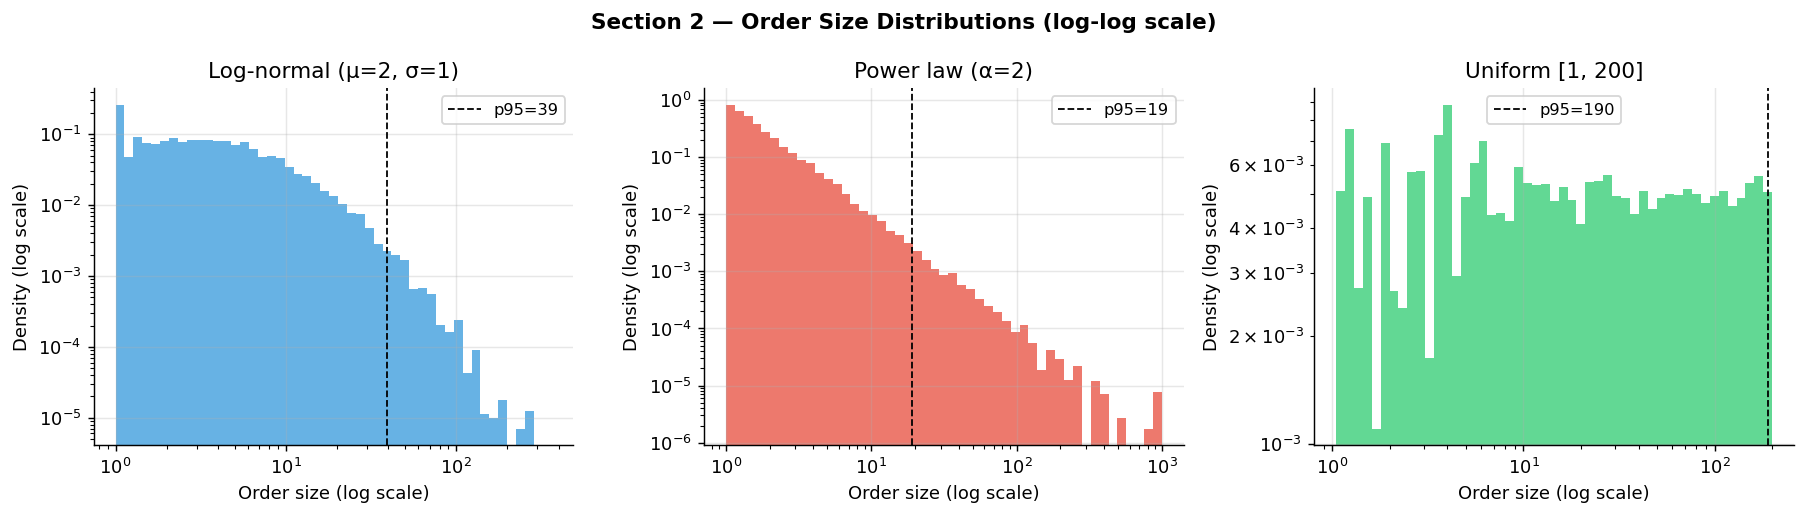

Log-normal    mean=12.4  median=7.4  p95=39.2  p99=78.1  max=363.4
Power law     mean=7.2  median=2.0  p95=19.1  p99=85.9  max=1000.0
Uniform       mean=101.6  median=102.2  p95=190.2  p99=198.4  max=200.0


In [3]:
dist_lognorm = OrderSizeDistribution(distribution="lognormal",
                                     mu_log=2.0, sigma_log=1.0, rng=RNG)
dist_power   = OrderSizeDistribution(distribution="powerlaw",
                                     alpha_pl=2.0, size_min=1.0, rng=RNG)
dist_uniform = OrderSizeDistribution(distribution="uniform",
                                     size_min=1.0, size_max=200.0, rng=RNG)

n_samples = 5000
s_ln  = dist_lognorm.sample(n_samples)
s_pl  = dist_power.sample(n_samples)
s_uni = dist_uniform.sample(n_samples)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, s, label, color in zip(
    axes,
    [s_ln, s_pl, s_uni],
    ["Log-normal (μ=2, σ=1)", "Power law (α=2)", "Uniform [1, 200]"],
    ["#3498db", "#e74c3c", "#2ecc71"],
):
    log_bins = np.logspace(np.log10(max(s.min(), 0.1)), np.log10(s.max()), 50)
    ax.hist(s, bins=log_bins, density=True, color=color, alpha=0.75)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("Order size (log scale)"); ax.set_ylabel("Density (log scale)")
    ax.set_title(label)
    p95 = np.percentile(s, 95)
    ax.axvline(p95, ls="--", color="black", lw=1, label=f"p95={p95:.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Section 2 — Order Size Distributions (log-log scale)", fontweight="bold")
plt.tight_layout()
plt.show()

for s, label in [(s_ln, "Log-normal"), (s_pl, "Power law"), (s_uni, "Uniform")]:
    print(f"{label:12s}  mean={s.mean():.1f}  median={np.median(s):.1f}  "
          f"p95={np.percentile(s,95):.1f}  p99={np.percentile(s,99):.1f}  "
          f"max={s.max():.1f}")

## Nhận xét — Order Size Distributions (log–log scale)

Hình này so sánh **ba giả định về phân phối kích thước lệnh $Q$**: Log-normal, Power law (Pareto) và Uniform.
Trục $x$ là **order size**, trục $y$ là **density**, cả hai đều ở **log scale** để quan sát rõ hành vi của **tail** (các giá trị lớn hiếm gặp).

Các đường đứt là **95th percentile (p95)**, tức là giá trị $Q$ sao cho:

$$
P(Q \le p95) = 0.95
$$

nghĩa là **95% orders nhỏ hơn giá trị đó**.

Density là **xác suất tương đối của một giá trị trong phân phối liên tục**.

Nếu $Q$ là order size thì:

$$
f(q)
$$

là **probability density function (PDF)**.

Ý nghĩa:

$$
P(a < Q < b) = \int_a^b f(q)\,dq
$$

tức là **xác suất order size nằm trong khoảng đó**.


---

# 1. Log-normal distribution

### Biểu đồ đang làm gì

Histogram mô phỏng trường hợp:

$$
\log Q \sim \mathcal{N}(2,1)
$$

tức là order size được sinh từ **log-normal distribution**.

Đường đứt:


$$ p95 ≈ 39 $$


---

### Quan sát

- Density cao nhất ở **order size nhỏ (≈ 1–10)**
- Sau đó giảm dần khi size tăng
- Tail kéo dài đến khoảng **100–200**

Điều này nghĩa là:


đa số orders nhỏ
một số ít orders khá lớn


---

### Ý nghĩa

Log-normal có:

- tail **khá dày**
- nhưng giảm **nhanh hơn power law**

Do đó:

- phù hợp để mô hình hóa **phần trung tâm của distribution**
- nhưng **undestimate các order cực lớn**.

---

# 2. Power law (Pareto)

### Biểu đồ đang làm gì

Histogram của phân phối Pareto:

$$
P(Q > x) \sim x^{-\alpha}
$$

với:

$$
\alpha = 2
$$

Trên **log–log plot**, power law xuất hiện gần như **đường thẳng**.

Đường đứt:


$$ p95 ≈ 19 $$


---

### Quan sát

- Density giảm gần **tuyến tính trên log–log scale**
- Tail kéo dài rất xa
- vẫn có orders **100, 500, thậm chí 1000**

Mặc dù p95 nhỏ hơn log-normal, nhưng **tail dài hơn nhiều**.

---

### Ý nghĩa

Power law có **heavy tail mạnh**.

Điều này nghĩa là:


> large orders hiếm nhưng không quá hiếm


và xác suất xuất hiện **extreme orders** vẫn đáng kể.

Đây là đặc điểm thường thấy trong **institutional order flow**.

---

# 3. Uniform distribution

### Biểu đồ đang làm gì

Order size được lấy ngẫu nhiên:


Q ~ Uniform[1,200]


Đường đứt:


$ p95 ≈ 190 $


---

### Quan sát

Histogram gần như **phẳng**.

Mỗi order size trong khoảng **1–200** có xác suất gần như bằng nhau.

Không có:

- peak ở small orders
- tail structure.

---

### Ý nghĩa

Uniform **không phản ánh thị trường thực**.

Trong dữ liệu market microstructure:


small orders nhiều hơn large orders


nhưng uniform giả định:


mọi size đều equally likely


---

# So sánh ba phân phối

| Distribution | Small orders | Large orders | Tail |
|---|---|---|---|
| Log-normal | nhiều | ít | trung bình |
| Power law | nhiều | vẫn xuất hiện | rất dày |
| Uniform | ngang nhau | ngang nhau | không có |

---

# Ý nghĩa đối với mô hình thị trường

Trong dữ liệu thực:

- order sizes thường **heavy-tailed**
- tail gần **power law hoặc log-normal**

Điều này quan trọng vì:


> large orders → price impact lớn


và có thể tạo ra:

- **liquidity shocks**
- **fat tails trong return distribution**.

Do đó các market simulation thường dùng:


> log-normal hoặc power law


thay vì uniform.

## 3. Trade Sign Classification

Trong raw trade tape, ta chỉ thấy price và quantity — không biết bên nào là aggressor. Cần gán **trade sign** (+1 buy-initiated, −1 sell-initiated) để tính OFI và adverse selection.

**Tick rule** (simplest):
$$s_t = \text{sign}(\Delta p_t), \quad \text{carry forward nếu } \Delta p_t = 0$$

**Lee & Ready (1991):** so sánh trade price với prevailing quote midpoint:
$$s_t = \begin{cases} +1 & \text{if } p_t > m_t \\ -1 & \text{if } p_t < m_t \\ \text{tick rule} & \text{if } p_t = m_t \end{cases}$$

Lee-Ready chính xác hơn tick rule vì dùng thêm thông tin từ quote. Sai số của cả hai tăng khi spread hẹp (nhiều trades tại midpoint) và khi có algorithmic trading tốc độ cao.

**Bulk Volume Classification (BVC)** (Easley et al. 2012): phân loại theo bar thay vì tick:
$$V^B_t = V_t \cdot \Phi\!\left(\frac{C_t - O_t}{\sigma}\right), \quad V^S_t = V_t - V^B_t$$

BVC phù hợp khi không có quote data (chỉ có OHLCV bars).

## Một số khái niệm cần hiểu trước khi đọc Trade Sign Classification

Phần này giải quyết một vấn đề quan trọng trong **market microstructure**:
từ dữ liệu trade thô (price, volume) làm sao biết **ai là người chủ động giao dịch**.

---

# 1. Aggressor là gì

Trong một giao dịch luôn có **2 phía**:

- người **đặt limit order** (cung cấp thanh khoản)
- người **đặt market order** (lấy thanh khoản)

Người dùng **market order** gọi là **aggressor**.

Ví dụ:

| Bid | Ask |
|---|---|
| 99 | 100 |

Nếu một trader **mua ngay tại giá 100**:


> market buy


→ trader đó là **buy aggressor**.

Nếu trader **bán ngay tại 99**:


> market sell


→ trader đó là **sell aggressor**.

---

# 2. Trade sign

**Trade sign** cho biết phía aggressor.

Ký hiệu:

$$
s_t
$$

Giá trị:

| Trade type | Sign |
|---|---|
| Buy initiated | +1 |
| Sell initiated | −1 |

Ý nghĩa:


> +1 → buyer là người chủ động

> -1 → seller là người chủ động


Trade sign rất quan trọng vì nó đo **order flow direction**.

---

# 3. Vì sao raw data không có trade sign

Trong **trade tape** thông thường ta chỉ thấy:

| Time | Price | Volume |
|---|---|---|
| 10:01 | 100 | 5 |
| 10:01 | 100 | 2 |

Không có thông tin:


> trade này là buy hay sell


Vì vậy cần **trade classification algorithm** để suy ra.

---

# 4. Tick rule

Tick rule là phương pháp đơn giản nhất.

Công thức:

$$
s_t = \text{sign}(\Delta p_t)
$$

trong đó:

$$
\Delta p_t = p_t - p_{t-1}
$$

---

### Cách hoạt động

| Price movement | Trade sign |
|---|---|
| price tăng | buy |
| price giảm | sell |

Ví dụ:

| Trade | Price | Sign |
|---|---|---|
| 1 | 100 | - |
| 2 | 101 | +1 |
| 3 | 101 | +1 (carry forward) |
| 4 | 100 | -1 |

Nếu:


$$ Δp = 0 $$


thì **giữ sign của trade trước**.

---

# 5. Lee–Ready algorithm

Lee & Ready (1991) dùng thêm **quote information**.

Quote midpoint:

$$
m_t = \frac{bid_t + ask_t}{2}
$$

Phân loại:

$$
s_t =
\begin{cases}
+1 & p_t > m_t \\
-1 & p_t < m_t \\
\text{tick rule} & p_t = m_t
\end{cases}
$$

---

### Ý tưởng trực giác

Nếu trade price:

| Price vs midpoint | Interpretation |
|---|---|
| $p_t > m_t$ | buyer aggressor |
| $p_t < m_t$ | seller aggressor |

Ví dụ:

| Bid | Ask | Midpoint |
|---|---|---|
| 99 | 100 | 99.5 |

Trade:


$$ price = 100 $$


→ buyer hit ask
→ **buy trade**.

---

# 6. Vì sao Lee–Ready chính xác hơn

Tick rule chỉ nhìn **price movement**.

Lee–Ready nhìn **price relative to bid–ask spread**.

Ví dụ:

| Bid | Ask | Trade price |
|---|---|---|
| 99 | 100 | 100 |

Tick rule:


> price unchanged → ambiguous


Lee–Ready:


> trade tại ask → buyer aggressor


---

# 7. Bulk Volume Classification (BVC)

BVC dùng khi **không có trade-level data**, chỉ có **OHLCV bars**.

Công thức:

$$
V^B_t = V_t \cdot \Phi\!\left(\frac{C_t - O_t}{\sigma}\right)
$$

$$
V^S_t = V_t - V^B_t
$$

Trong đó:

| Symbol | Meaning |
|---|---|
| $V_t$ | total volume |
| $C_t$ | close price |
| $O_t$ | open price |
| $\sigma$ | volatility |
| $\Phi$ | Gaussian CDF |

---

### Ý tưởng

Nếu bar **đóng cao hơn mở**:


> close > open


→ nhiều khả năng **buy pressure**.

Nếu:


> close < open


→ **sell pressure**.

BVC dùng điều này để chia volume thành:

> buy volume
> sell volume


---

# 8. Vì sao trade sign quan trọng

Trade sign là nền tảng cho nhiều metric microstructure:

### Order Flow Imbalance

$$
OFI_t = \sum s_t \cdot v_t
$$

---

### Adverse selection

Market makers quan sát:


> nhiều buy trades liên tiếp


→ khả năng có **informed trader**.

---

# 9. Lưu ý quan trọng

Cả ba phương pháp đều **không hoàn hảo**.

Sai số tăng khi:

- spread rất hẹp
- nhiều trades tại midpoint
- algorithmic trading tốc độ cao

Do đó trade classification luôn có **classification error**.

## Tick Rule và Lee–Ready Algorithm

Hai phương pháp này đều nhằm **suy ra trade sign** (hướng của giao dịch) từ dữ liệu thị trường.
Trade sign ký hiệu:

$$
s_t \in \{-1, +1\}
$$

| Giá trị | Ý nghĩa |
|---|---|
| $+1$ | buyer là aggressor |
| $-1$ | seller là aggressor |

Nói cách khác, ta đang cố xác định:

$$
\text{ai là người chủ động giao dịch}
$$

---

# 1. Tick Rule

## Ý tưởng

Tick rule dựa trên giả định trực quan:

> nếu giao dịch làm **giá tăng**, thì người mua là người chủ động.

> nếu giao dịch làm **giá giảm**, thì người bán là người chủ động.

Thuật toán chỉ sử dụng **chuỗi giá giao dịch**.

---

## Công thức

Giả sử:

$$
p_t
$$

là giá của trade thứ $t$.

Khi đó:

$$
s_t = \text{sign}(p_t - p_{t-1})
$$

---

## Quy tắc phân loại

| Điều kiện | Trade sign |
|---|---|
| $p_t > p_{t-1}$ | Buy ($+1$) |
| $p_t < p_{t-1}$ | Sell ($-1$) |

Nếu:

$$
p_t = p_{t-1}
$$

thì:

> giữ trade sign của giao dịch trước đó.

---

## Ví dụ

Chuỗi giá:

| Trade | Price |
|---|---|
| 1 | 100 |
| 2 | 101 |
| 3 | 101 |
| 4 | 100 |

Phân loại:

| Trade | Price | $s_t$ |
|---|---|---|
| 1 | 100 | – |
| 2 | 101 | +1 |
| 3 | 101 | +1 |
| 4 | 100 | −1 |

Giải thích:

- Trade 2: giá tăng → buyer aggressor
- Trade 3: giá không đổi → giữ sign trước
- Trade 4: giá giảm → seller aggressor

---

## Hạn chế của Tick Rule

Tick rule **không biết bid–ask spread**.

Ví dụ:

| Bid | Ask |
|---|---|
| 99 | 100 |

Giả sử hai trade liên tiếp đều xảy ra tại:

$$
price = 100
$$

Điều này có thể xảy ra khi:

> nhiều buyer liên tiếp hit ask.

Nhưng tick rule thấy:

$$
p_t - p_{t-1} = 0
$$

→ không thể xác định direction chính xác.

Do đó tick rule có thể **misclassify trade direction**.

---

# 2. Lee–Ready Algorithm

Lee–Ready (1991) cải thiện tick rule bằng cách sử dụng thêm **quote information**.

Cụ thể:

- bid
- ask

---

## Midpoint

Từ bid và ask ta tính midpoint:

$$
m_t = \frac{bid_t + ask_t}{2}
$$

Midpoint đại diện cho **giá cân bằng giữa bên mua và bên bán**.

---

## Quy tắc phân loại

Lee–Ready so sánh **trade price với midpoint**.

$$
s_t =
\begin{cases}
+1 & p_t > m_t \\
-1 & p_t < m_t \\
\text{tick rule} & p_t = m_t
\end{cases}
$$

---

## Ý nghĩa trực giác

Nếu:

$$
p_t > m_t
$$

thì trade xảy ra **gần ask**.

Điều này thường xảy ra khi:

> buyer dùng market order và **hit ask**.

→ buyer là aggressor.

---

Nếu:

$$
p_t < m_t
$$

thì trade xảy ra **gần bid**.

Điều này xảy ra khi:

> seller dùng market order và **hit bid**.

→ seller là aggressor.

---

Nếu:

$$
p_t = m_t
$$

thì:

không thể biết trade xảy ra ở phía nào.

Thuật toán sẽ quay lại dùng **tick rule**.

---

# 3. Ví dụ

Giả sử order book:

| Bid | Ask |
|---|---|
| 99 | 100 |

Midpoint:

$$
m = 99.5
$$

---

### Trade 1

$$
p = 100
$$

Ta có:

$$
100 > 99.5
$$

→ trade gần ask

→ **buy trade**

---

### Trade 2

$$
p = 99
$$

Ta có:

$$
99 < 99.5
$$

→ trade gần bid

→ **sell trade**

---

# 4. So sánh hai phương pháp

| Method | Data cần | Ý tưởng |
|---|---|---|
| Tick rule | trade prices | nhìn biến động giá |
| Lee–Ready | trade + bid/ask | so sánh với midpoint |

Tick rule sử dụng:

$$
p_t - p_{t-1}
$$

Lee–Ready sử dụng:

$$
p_t - m_t
$$

---

# 5. Vì sao Lee–Ready chính xác hơn

Tick rule giả định:

> buyer làm giá tăng.

Nhưng trong thực tế:

- nhiều trade xảy ra **cùng một giá**
- bid–ask spread tồn tại

Do đó price change **không phải lúc nào cũng phản ánh direction của trade**.

Lee–Ready giải quyết vấn đề này bằng cách sử dụng **thông tin từ order book**.

Nhờ vậy ta biết trade xảy ra:

- gần bid
- hay gần ask

và có thể suy ra **aggressor side chính xác hơn**.

---

# 6. Kết luận

Cả hai phương pháp đều cố giải bài toán:

$$
\text{trade price} \rightarrow \text{trade direction}
$$

- **Tick rule**: dùng biến động giá
- **Lee–Ready**: dùng vị trí của trade trong bid–ask spread

Trong dữ liệu thực tế:

| Method | Accuracy |
|---|---|
| Tick rule | ~60–70% |
| Lee–Ready | ~70–85% |

Vì vậy Lee–Ready thường được dùng khi có **quote data**.


Tick rule accuracy vs ground truth : 88.0%
Lee-Ready accuracy vs ground truth : 74.2%


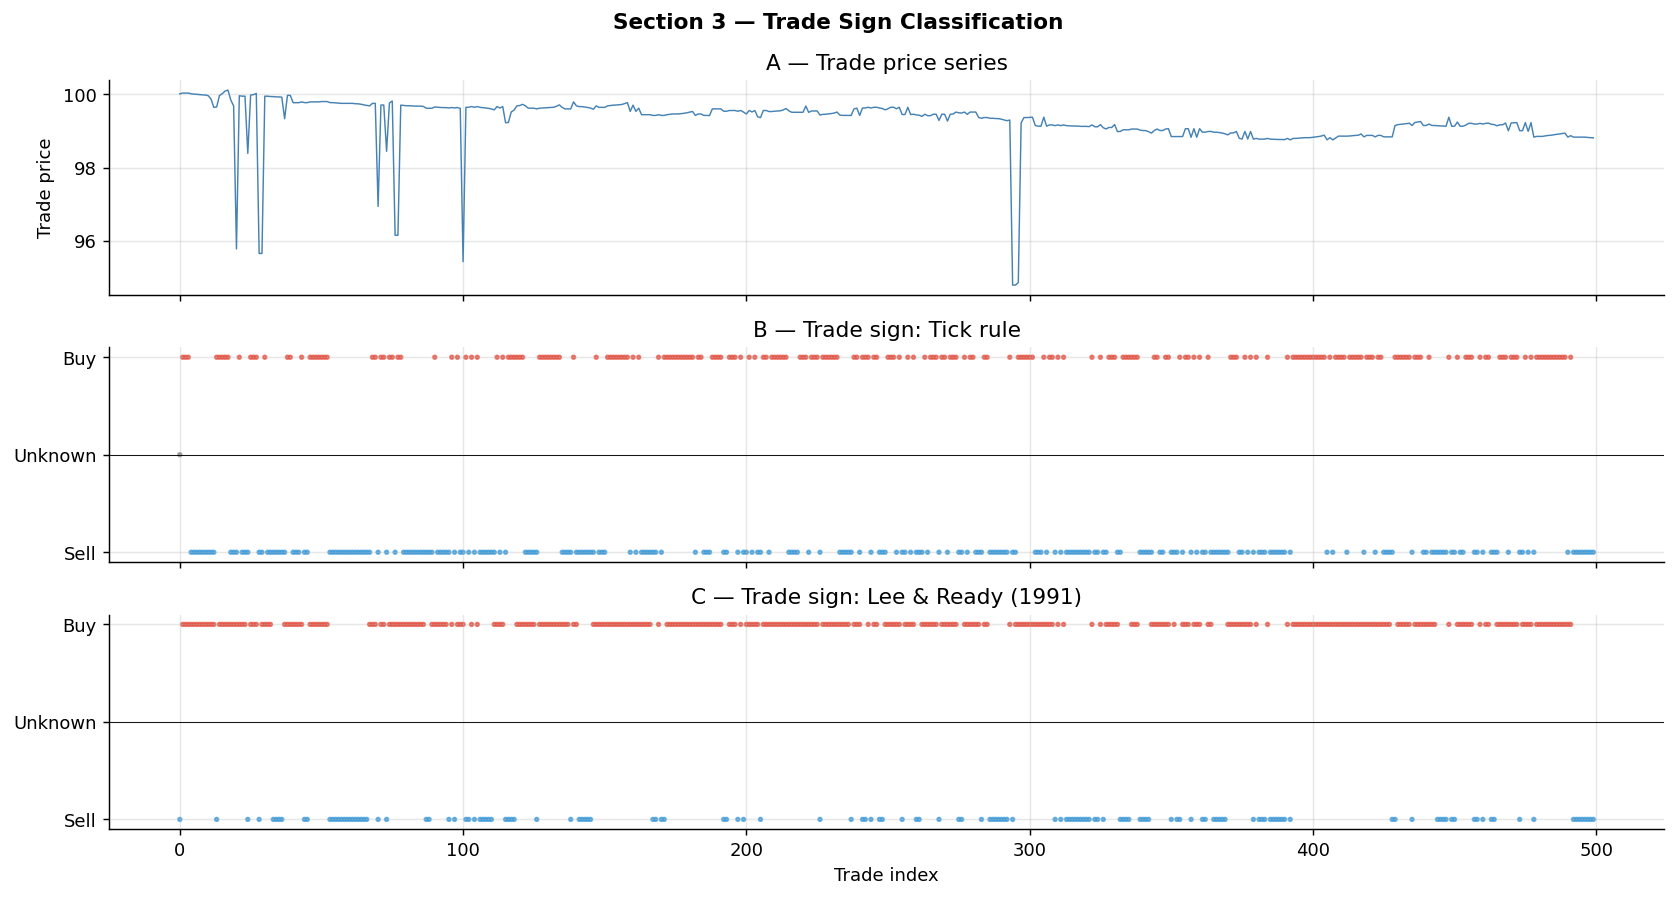

Tick rule     buy=242  sell=257  unknown=  1  imbalance=-0.030
Lee-Ready     buy=352  sell=148  unknown=  0  imbalance=+0.408


In [4]:
trade_prices = np.array([t["price"] for t in trades]) if trades else prices
trade_prices = trade_prices[:500]

trade_bids = np.array([t["best_bid"] for t in trades[:500]])
trade_asks = np.array([t["best_ask"] for t in trades[:500]])

tick_signs = TradeClassifier.tick_rule(list(trade_prices))
lr_signs   = TradeClassifier.lee_ready(
                 list(trade_prices),
                 list(trade_bids),
                 list(trade_asks))

gt_signs = [t.get("sign", 0) for t in trades[:500]] if trades else []

tick_int = np.array([s.value for s in tick_signs])
lr_int   = np.array([s.value for s in lr_signs])
gt_int   = np.array(gt_signs) if gt_signs else None

if gt_int is not None and len(gt_int) > 0:
    valid    = gt_int != 0
    tick_acc = (tick_int[valid] == gt_int[valid]).mean()
    lr_acc   = (lr_int[valid]   == gt_int[valid]).mean()
    print(f"Tick rule accuracy vs ground truth : {tick_acc:.1%}")
    print(f"Lee-Ready accuracy vs ground truth : {lr_acc:.1%}")

fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(trade_prices, lw=0.8, color="steelblue")
ax.set_ylabel("Trade price"); ax.set_title("A — Trade price series")

ax = axes[1]
colors_tick = ["#e74c3c" if s == 1 else "#3498db" if s == -1 else "grey"
               for s in tick_int]
ax.scatter(range(len(tick_int)), tick_int, c=colors_tick, s=4, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["Sell", "Unknown", "Buy"])
ax.set_title("B — Trade sign: Tick rule")

ax = axes[2]
colors_lr = ["#e74c3c" if s == 1 else "#3498db" if s == -1 else "grey"
             for s in lr_int]
ax.scatter(range(len(lr_int)), lr_int, c=colors_lr, s=4, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_yticks([-1, 0, 1]); ax.set_yticklabels(["Sell", "Unknown", "Buy"])
ax.set_xlabel("Trade index"); ax.set_title("C — Trade sign: Lee & Ready (1991)")

plt.suptitle("Section 3 — Trade Sign Classification", fontweight="bold")
plt.tight_layout()
plt.show()

for signs, label in [(tick_int, "Tick rule"), (lr_int, "Lee-Ready")]:
    buys  = (signs ==  1).sum()
    sells = (signs == -1).sum()
    unk   = (signs ==  0).sum()
    imb   = (buys - sells) / (buys + sells) if buys + sells > 0 else 0
    print(f"{label:12s}  buy={buys:3d}  sell={sells:3d}  "
          f"unknown={unk:3d}  imbalance={imb:+.3f}")

# Trade Sign Classification — Simulation Analysis

## 1. Mục tiêu của biểu đồ

Biểu đồ minh họa cách **hai thuật toán phân loại trade sign** hoạt động trên cùng một chuỗi giao dịch:

- **Tick rule**
- **Lee–Ready algorithm**

Trade sign được ký hiệu:

$$
s_t \in \{-1, +1\}
$$

| Sign | Ý nghĩa |
|---|---|
| $+1$ | buyer aggressor |
| $-1$ | seller aggressor |

Mục tiêu của simulation là kiểm tra:

$$
\text{trade prices} \rightarrow \text{trade direction inference}
$$

và đánh giá **độ chính xác của các thuật toán so với ground truth**.

---

# 2. Panel A — Trade price series

Panel A hiển thị chuỗi giá giao dịch:

$$
p_t
$$

Trục:

- **x-axis:** trade index
- **y-axis:** trade price

Quan sát:

- Giá dao động quanh **98–100**
- Phần lớn biến động nhỏ
- Có một số **điểm giảm mạnh đột ngột**

### Ý nghĩa của các cú giảm mạnh

Các cú giảm mạnh xảy ra khi:

- market sell lớn
- ăn nhiều level trong order book

Do đó:

$$
p_t \ll p_{t-1}
$$

→ **sell aggressor mạnh**

Điều này tạo ra các **price jumps** trong chuỗi giá.

---

# 3. Panel B — Trade sign theo Tick rule

Tick rule phân loại theo:

$$
s_t = \text{sign}(p_t - p_{t-1})
$$

Quy tắc:

| Điều kiện | Phân loại |
|---|---|
| $p_t > p_{t-1}$ | Buy |
| $p_t < p_{t-1}$ | Sell |

Nếu:

$$
p_t = p_{t-1}
$$

→ giữ sign trước.

### Quan sát từ biểu đồ

Các điểm đỏ và xanh phân bố **khá cân bằng**.

Thống kê:

| Metric | Value |
|---|---|
| Buy trades | 242 |
| Sell trades | 257 |
| Unknown | 1 |

Order flow imbalance:

$$
OFI \approx -0.030
$$

Điều này cho thấy:

- buy và sell gần như **cân bằng**
- order flow không thiên lệch rõ rệt.

### Độ chính xác

Tick rule đạt:

$$
Accuracy = 88.0\%
$$

Điều này cho thấy **price movement trong simulation phản ánh khá tốt direction của trade**.

---

# 4. Panel C — Trade sign theo Lee–Ready

Lee–Ready phân loại dựa trên **midpoint của bid–ask spread**.

Midpoint:

$$
m_t = \frac{bid_t + ask_t}{2}
$$

Quy tắc:

$$
s_t =
\begin{cases}
+1 & p_t > m_t \\
-1 & p_t < m_t \\
\text{tick rule} & p_t = m_t
\end{cases}
$$

### Quan sát từ biểu đồ

Các điểm buy **chiếm ưu thế rõ rệt**.

Thống kê:

| Metric | Value |
|---|---|
| Buy trades | 352 |
| Sell trades | 148 |
| Unknown | 0 |

Order flow imbalance:

$$
OFI \approx +0.408
$$

Điều này cho thấy Lee–Ready suy ra **buy pressure mạnh**.

---

# 5. So sánh hai thuật toán

| Metric | Tick rule | Lee–Ready |
|---|---|---|
| Accuracy | **88.0%** | 74.2% |
| Buy trades | 242 | 352 |
| Sell trades | 257 | 148 |
| Imbalance | −0.030 | +0.408 |

### Nhận xét quan trọng

Tick rule:

- cho **buy và sell khá cân bằng**
- gần với **ground truth**

Lee–Ready:

- gán quá nhiều **buy trades**
- tạo ra **buy imbalance lớn**

---

# 6. Vì sao Lee–Ready kém chính xác trong simulation

Trong dữ liệu thực, Lee–Ready thường chính xác hơn vì nó dùng **bid–ask spread**.

Tuy nhiên trong simulation này có thể xảy ra các trường hợp:

### 1. Trade price thường nằm trên midpoint

Nếu nhiều giao dịch xảy ra:

$$
p_t > m_t
$$

thì Lee–Ready sẽ gán:

$$
s_t = +1
$$

→ buy trade.

Điều này làm tăng số **buy classification**.

---

### 2. Spread nhỏ

Khi spread rất nhỏ:

$$
ask - bid \rightarrow 0
$$

midpoint gần với trade price.

Trong trường hợp đó **noise nhỏ trong giá** có thể khiến Lee–Ready phân loại sai.

---

### 3. Simulation không mô hình hóa quote dynamics đầy đủ

Lee–Ready phụ thuộc vào:

- bid
- ask
- quote updates

Nếu simulation chỉ mô phỏng **trade price** mà không mô phỏng quote chính xác, thì midpoint có thể **không phản ánh đúng vị trí của trade trong order book**.

Do đó Lee–Ready dễ bị lệch.

---

# 7. Insight từ biểu đồ

### Insight 1 — Price movement chứa nhiều thông tin về trade direction

Tick rule chỉ dùng:

$$
p_t - p_{t-1}
$$

nhưng vẫn đạt:

$$
Accuracy = 88\%
$$

Điều này cho thấy:

> trong simulation, **price change đã phản ánh khá rõ aggressor side**.

---

### Insight 2 — Lee–Ready có thể bias nếu quote không chính xác

Lee–Ready giả định:

$$
p_t > m_t \Rightarrow \text{buyer aggressor}
$$

Nhưng nếu midpoint không phản ánh đúng order book, thuật toán có thể **systematically bias về một phía**.

Trong trường hợp này:

- Lee–Ready **bias về buy trades**.

---

# 8. Kết luận

Biểu đồ cho thấy cách hai thuật toán suy ra **trade direction từ dữ liệu giá**.

Kết quả simulation:

- **Tick rule** đạt độ chính xác cao hơn (88%)
- **Lee–Ready** bị bias về phía buy trades và kém chính xác hơn (74%)

Điều này cho thấy một điểm quan trọng trong market microstructure:

> độ chính xác của trade classification phụ thuộc mạnh vào **chất lượng dữ liệu quote**.

Nếu quote không phản ánh đúng trạng thái order book, phương pháp dựa trên midpoint như Lee–Ready có thể **kém hiệu quả hơn các phương pháp đơn giản như tick rule**.


## 4. Order Flow Imbalance (OFI)

OFI theo Cont, Kukanov & Stoikov (2014) đo sự thay đổi **queue tại best bid/ask**:

$$e^B_t = q^B_t \cdot \mathbf{1}[P^B_t \geq P^B_{t-1}] - q^B_{t-1} \cdot \mathbf{1}[P^B_t \leq P^B_{t-1}]$$
$$e^A_t = q^A_{t-1} \cdot \mathbf{1}[P^A_t \geq P^A_{t-1}] - q^A_t \cdot \mathbf{1}[P^A_t \leq P^A_{t-1}]$$
$$\text{OFI}_t = e^B_t - e^A_t$$

- **OFI > 0**: bid queue tăng hoặc ask queue giảm → net buying pressure → giá có xu hướng tăng
- **OFI < 0**: ngược lại

Về thực nghiệm, Cont et al. (2014) tìm thấy $R^2 \approx 0.65$–$0.85$ trong regression $\Delta p_t = \beta \cdot \text{OFI}_t + \varepsilon_t$, cao hơn đáng kể so với chỉ dùng signed volume.

Cumulative OFI là một leading indicator ngắn hạn của price movement — được dùng trong execution algorithms (VWAP, implementation shortfall) để đo lường market impact.

# 1. Limit Order Book (LOB)

Trong thị trường điện tử, giao dịch diễn ra thông qua **limit order book**.

Order book có hai phía:

| Side | Ý nghĩa |
|---|---|
| Bid | các lệnh mua đang chờ khớp |
| Ask | các lệnh bán đang chờ khớp |

Ví dụ:

| Bid price | Bid size | Ask price | Ask size |
|---|---|---|---|
| 99 | 10 | 100 | 12 |

Trong đó:

- **bid price**: giá cao nhất mà người mua sẵn sàng trả
- **ask price**: giá thấp nhất mà người bán sẵn sàng bán

Giá giao dịch thường nằm giữa hai mức này.

---

# 2. Best Bid và Best Ask

Trong order book có nhiều mức giá, nhưng mức quan trọng nhất là **best level**.

Ký hiệu:

- $P^B_t$ : best bid price tại thời điểm $t$
- $P^A_t$ : best ask price tại thời điểm $t$

Khối lượng tại mức này:

- $q^B_t$ : bid queue size
- $q^A_t$ : ask queue size

Ví dụ:

| Level | Bid | Ask |
|---|---|---|
| Best | 99 (10) | 100 (12) |

Ở đây:

$$
P^B_t = 99, \quad q^B_t = 10
$$

$$
P^A_t = 100, \quad q^A_t = 12
$$

---

# 3. Queue dynamics

Queue tại best bid/ask thay đổi khi:

### Limit orders

Trader đặt lệnh chờ:

- limit buy → tăng $q^B_t$
- limit sell → tăng $q^A_t$

---

### Market orders

Trader gửi market order:

- market buy → khớp với ask → giảm $q^A_t$
- market sell → khớp với bid → giảm $q^B_t$

---

### Order cancellations

Trader hủy lệnh:

- cancel bid → giảm $q^B_t$
- cancel ask → giảm $q^A_t$

---

Do đó queue size luôn biến động:

$$
q^B_t, q^A_t
$$

---

# 4. Order Flow Imbalance (OFI)

OFI được đề xuất bởi:

**Cont, Kukanov & Stoikov (2014)**.

Ý tưởng:

> đo **sự thay đổi của liquidity tại best bid và best ask**.

---

## Thành phần bid

Bid contribution:

$$
e^B_t = q^B_t \cdot \mathbf{1}[P^B_t \geq P^B_{t-1}]
      - q^B_{t-1} \cdot \mathbf{1}[P^B_t \leq P^B_{t-1}]
$$

Ý nghĩa:

- nếu bid price tăng hoặc giữ nguyên → liquidity bid tăng
- nếu bid price giảm → liquidity bid bị rút đi

---

## Thành phần ask

Ask contribution:

$$
e^A_t = q^A_{t-1} \cdot \mathbf{1}[P^A_t \geq P^A_{t-1}]
      - q^A_t \cdot \mathbf{1}[P^A_t \leq P^A_{t-1}]
$$

Ý nghĩa:

- nếu ask price tăng → liquidity sell tăng
- nếu ask giảm → liquidity ask bị ăn bởi buyer

---

## OFI tổng

Order flow imbalance:

$$
\text{OFI}_t = e^B_t - e^A_t
$$

---

# 5. Ý nghĩa trực giác của OFI

OFI đo **sự mất cân bằng giữa liquidity bid và ask**.

---

### Trường hợp OFI > 0

$$
\text{OFI}_t > 0
$$

Điều này xảy ra khi:

- bid queue tăng
- ask queue giảm

Nghĩa là:

> có **buy pressure**

Buyer đang:

- đặt limit buy
- hoặc ăn ask

Do đó giá có xu hướng:

$$
\Delta p_t > 0
$$

---

### Trường hợp OFI < 0

$$
\text{OFI}_t < 0
$$

Xảy ra khi:

- bid queue giảm
- ask queue tăng

Điều này nghĩa là:

> **sell pressure**

Do đó giá có xu hướng giảm.

---

# 6. Price impact regression

Cont et al. (2014) cho thấy OFI giải thích price movement khá tốt.

Regression:

$$
\Delta p_t = \beta \cdot \text{OFI}_t + \varepsilon_t
$$

Trong dữ liệu thực:

$$
R^2 \approx 0.65 - 0.85
$$

Điều này nghĩa là:

> phần lớn biến động giá ngắn hạn được giải thích bởi **order book imbalance**.

---

# 7. Signed Volume

Một thước đo đơn giản hơn là **signed volume**.

Ký hiệu:

$$
SV_t = s_t \cdot v_t
$$

Trong đó:

- $s_t$ : trade sign
- $v_t$ : trade volume

Signed volume đo:

> net aggressive trading.

Tuy nhiên signed volume **không quan sát queue dynamics**, vì vậy thường kém chính xác hơn OFI.

---

# 8. Cumulative measures

Trong phân tích microstructure thường dùng **cumulative sums**.

### Cumulative OFI

$$
\text{CumOFI}_t = \sum_{i=1}^{t} \text{OFI}_i
$$

Nó cho thấy:

> tổng buy/sell pressure tích lũy.

---

### Cumulative signed volume

$$
\text{CumSV}_t = \sum_{i=1}^{t} SV_i
$$

Thường được so sánh với price path để kiểm tra:

$$
\text{order flow} \rightarrow \text{price impact}
$$

---

# 9. Lagged cross-correlation

Để kiểm tra OFI có dự báo được price hay không, ta tính:

$$
Corr(\text{OFI}_t, r_{t+k})
$$

Trong đó:

$$
r_t = p_t - p_{t-1}
$$

Nếu:

$$
Corr(\text{OFI}_t, r_{t+1}) > 0
$$

thì OFI có **predictive power** cho return tương lai.

---

# 10. Simulation vs Real Market

Trong **real L2 order book data**:

- OFI thường có predictive power mạnh
- price impact rõ ràng

Tuy nhiên trong simulation đơn giản:

- price thường được sinh từ **exogenous process**
- order book dynamics không đầy đủ

Do đó:

> OFI có thể **không dự báo được price movement mạnh như dữ liệu thật**.

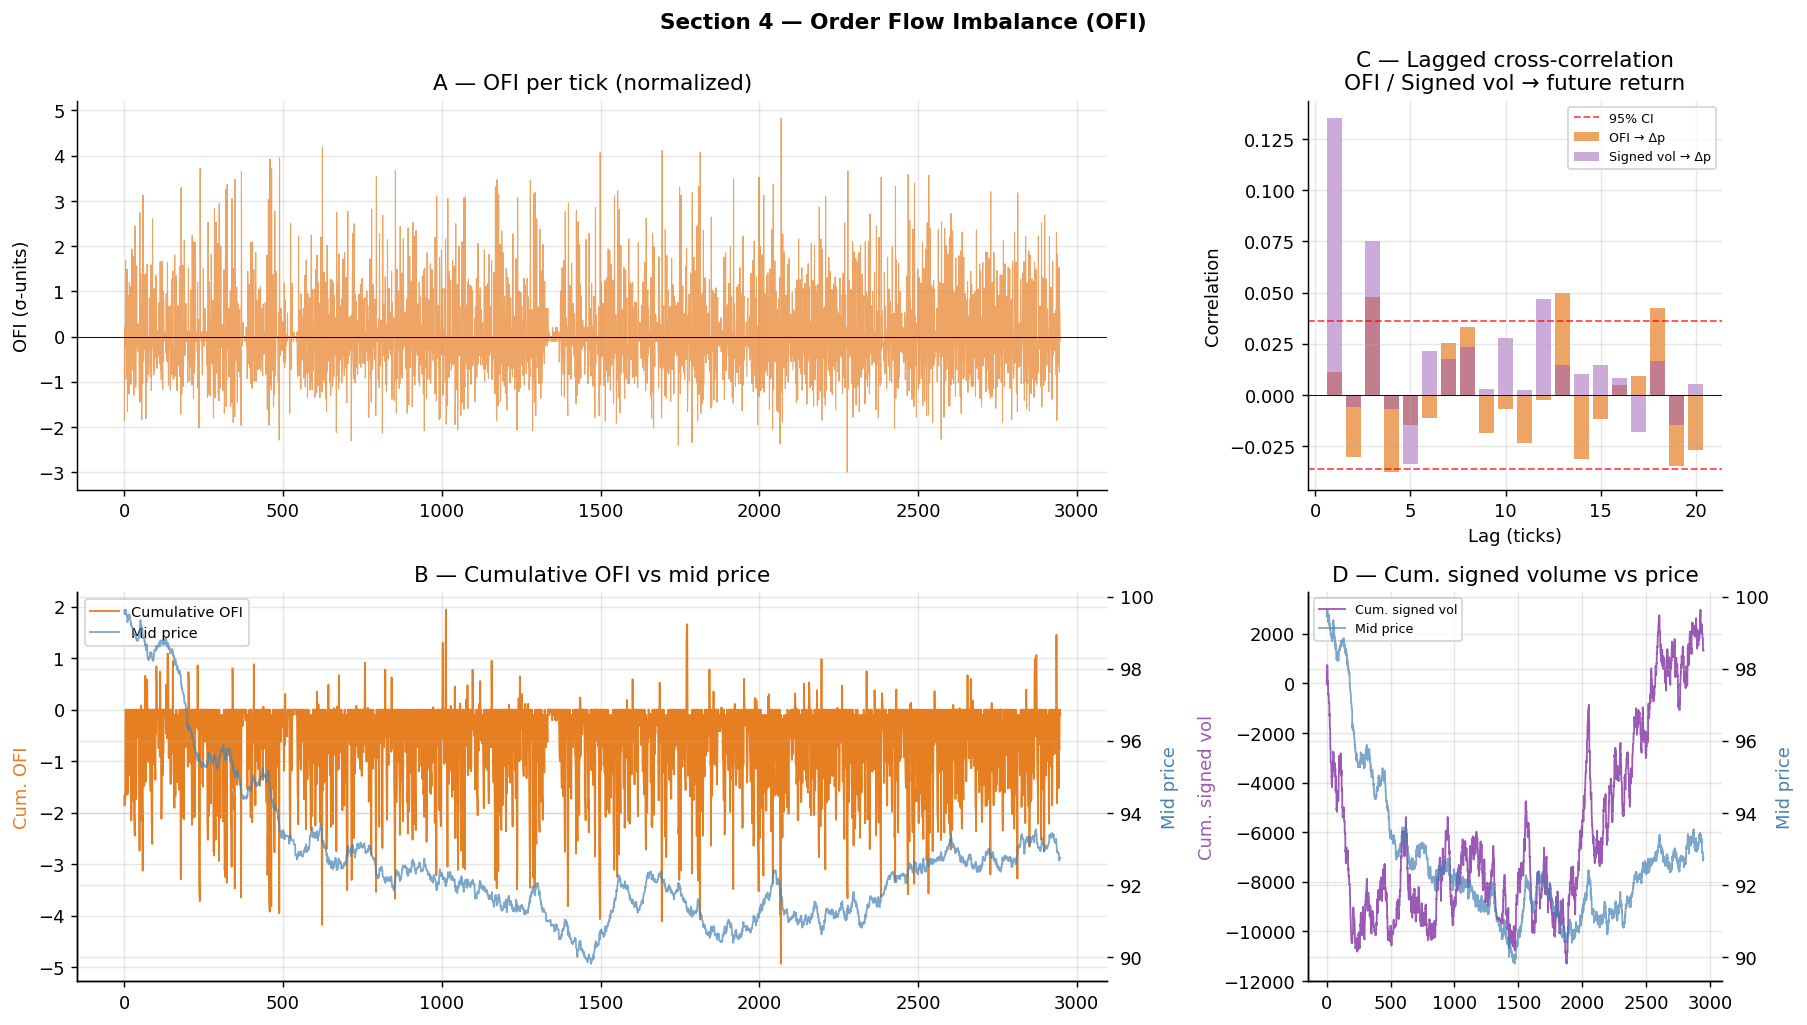

Lagged cross-correlation OFI → return:
  lag= 1  corr=+0.0114
  lag= 2  corr=-0.0302
  lag= 3  corr=+0.0481
  lag= 4  corr=-0.0377
  lag= 5  corr=-0.0147

Note: price formation driven by fundamental process (depth_refresh=5).
OFI predictive power là đặc trưng của real L2 data, không phải aggregated-book sim.


In [6]:
# OFI proxy từ best bid/ask price changes
bb = result.best_bids
ba = result.best_asks
d_bid = np.diff(bb)
d_ask = np.diff(ba)
ofi_fresh = d_bid - d_ask
ofi_fresh = ofi_fresh / (np.std(ofi_fresh) + 1e-10)
cum_ofi   = np.cumsum(ofi_fresh)

sv      = result.signed_volume()
cum_sv  = np.cumsum(sv)
returns = np.diff(prices)

# align lengths trước
n_min = min(len(ofi_fresh), len(sv), len(returns))
ofi_a = ofi_fresh[:n_min]
sv_a  = sv[:n_min]
ret_a = returns[:n_min]

max_lag  = 20
lags     = np.arange(1, max_lag + 1)
xcorr    = [np.corrcoef(ofi_a[:-k], ret_a[k:])[0,1] for k in lags]
xcorr_sv = [np.corrcoef(sv_a[:-k],  ret_a[k:])[0,1] for k in lags]

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig)

ax = fig.add_subplot(gs[0, :2])
ax.plot(ofi_fresh, lw=0.6, color="#e67e22", alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("A — OFI per tick (normalized)"); ax.set_ylabel("OFI (σ-units)")

ax  = fig.add_subplot(gs[1, :2])
ax2 = ax.twinx()
ax.plot(cum_ofi, color="#e67e22", lw=1, label="Cumulative OFI")
ax2.plot(prices[1:len(cum_ofi)+1], color="steelblue", lw=1, alpha=0.7, label="Mid price")
ax.set_ylabel("Cum. OFI", color="#e67e22")
ax2.set_ylabel("Mid price", color="steelblue")
ax.set_title("B — Cumulative OFI vs mid price")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

# Panel C — lagged cross-correlation
ax = fig.add_subplot(gs[0, 2])
conf = 1.96 / np.sqrt(len(returns))
ax.bar(lags, xcorr,    alpha=0.7, color="#e67e22", label="OFI → Δp")
ax.bar(lags, xcorr_sv, alpha=0.5, color="#9b59b6", label="Signed vol → Δp")
ax.axhline( conf, ls="--", color="red", lw=1, alpha=0.7, label="95% CI")
ax.axhline(-conf, ls="--", color="red", lw=1, alpha=0.7)
ax.axhline(0, color="black", lw=0.5)
ax.set_xlabel("Lag (ticks)"); ax.set_ylabel("Correlation")
ax.set_title("C — Lagged cross-correlation\nOFI / Signed vol → future return")
ax.legend(fontsize=7)

# Panel D — cumulative signed volume vs price
ax  = fig.add_subplot(gs[1, 2])
ax2 = ax.twinx()
ax.plot(cum_sv, color="#9b59b6", lw=1, label="Cum. signed vol")
ax2.plot(prices[:len(cum_sv)], color="steelblue", lw=1, alpha=0.7, label="Mid price")
ax.set_ylabel("Cum. signed vol", color="#9b59b6")
ax2.set_ylabel("Mid price", color="steelblue")
ax.set_title("D — Cum. signed volume vs price")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7)

plt.suptitle("Section 4 — Order Flow Imbalance (OFI)", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Lagged cross-correlation OFI → return:")
for k, c in zip(lags[:5], xcorr[:5]):
    print(f"  lag={k:2d}  corr={c:+.4f}")
print(f"\nNote: price formation driven by fundamental process (depth_refresh={sim.depth_refresh}).")
print(f"OFI predictive power là đặc trưng của real L2 data, không phải aggregated-book sim.")

# Phân tích biểu đồ — Order Flow Imbalance (OFI)

Biểu đồ này minh họa mối quan hệ giữa **order book imbalance**, **signed trading volume** và **price dynamics** trong một mô phỏng thị trường.
Mục tiêu là kiểm tra liệu **OFI hoặc signed volume có thể dự báo biến động giá ngắn hạn hay không**.

Các panel được chia thành bốn phần: A, B, C, D.

---

# A — OFI per tick (normalized)

Panel A hiển thị chuỗi:

$$
\text{OFI}_t
$$

đã được chuẩn hóa theo độ lệch chuẩn:

$$
\text{OFI}^{norm}_t = \frac{\text{OFI}_t}{\sigma(\text{OFI})}
$$

Trục:

- **x-axis:** trade ticks
- **y-axis:** OFI (đơn vị σ)

### Quan sát

Chuỗi OFI dao động quanh:

$$
0
$$

với biên độ khoảng:

$$
[-3, 5]
$$

Điều này có nghĩa:

- có những thời điểm **buy pressure mạnh** (OFI > 0)
- có những thời điểm **sell pressure mạnh** (OFI < 0)

Nhưng phần lớn giá trị nằm gần 0.

### Ý nghĩa

OFI là một **process có mean gần 0**, phản ánh rằng:

> về dài hạn, lượng thanh khoản thêm vào bid và ask khá cân bằng.

Các spike lớn thể hiện những thời điểm:

- nhiều lệnh limit buy được thêm vào
- hoặc nhiều ask bị market buy ăn hết.

---

# B — Cumulative OFI vs mid price

Panel B so sánh hai chuỗi:

- **Cumulative OFI**

$$
\text{CumOFI}_t = \sum_{i=1}^{t} \text{OFI}_i
$$

- **Mid price**

$$
m_t = \frac{P^B_t + P^A_t}{2}
$$

### Cách đọc biểu đồ

Nếu OFI là driver của price impact, ta kỳ vọng:

$$
\text{CumOFI}_t \uparrow
\quad \Rightarrow \quad
m_t \uparrow
$$

và ngược lại.

### Quan sát

Trong biểu đồ:

- cumulative OFI giảm dần theo thời gian
- mid price cũng có xu hướng giảm.

Hai chuỗi có **direction tương tự trong nhiều đoạn**.

Ví dụ:

- giai đoạn đầu: CumOFI giảm → price giảm
- giai đoạn cuối: CumOFI tăng nhẹ → price phục hồi.

### Ý nghĩa

Điều này phù hợp với lý thuyết:

> **liquidity imbalance tại best quotes có thể đẩy giá di chuyển.**

Tuy nhiên mối quan hệ **không hoàn toàn tuyến tính**.

Nguyên nhân:

- price còn chịu tác động từ process cơ bản trong simulation
- OFI chỉ phản ánh **short-term order book pressure**.

---

# C — Lagged cross-correlation

Panel C đo:

$$
Corr(\text{OFI}_t, r_{t+k})
$$

với:

$$
r_t = p_t - p_{t-1}
$$

Thanh màu:

- cam: OFI → future return
- tím: signed volume → future return

Đường đỏ đứt đoạn là **95% confidence interval**:

$$
\pm \frac{1.96}{\sqrt{N}}
$$

### Quan sát

Một số lag nhỏ có correlation dương, nhưng:

- phần lớn nằm **trong confidence interval**
- correlation khá nhỏ.

Điều này cho thấy:

> OFI **không có predictive power mạnh** trong simulation.

Signed volume đôi khi có correlation cao hơn ở lag nhỏ, nhưng cũng không ổn định.

### Ý nghĩa

Trong **real market data**, nghiên cứu của Cont et al. (2014) thường tìm thấy:

$$
R^2 \approx 0.65 - 0.85
$$

khi regression:

$$
\Delta p_t = \beta \cdot \text{OFI}_t + \varepsilon_t
$$

Nhưng trong simulation này correlation thấp vì:

- price được sinh từ **exogenous process**
- order book dynamics không phải driver chính của price.

---

# D — Cumulative signed volume vs price

Panel D so sánh:

- **cumulative signed volume**

$$
\text{CumSV}_t = \sum_{i=1}^{t} s_i v_i
$$

- **mid price**

### Quan sát

Cumulative signed volume dao động rất mạnh:

- từ khoảng −11000 đến +2000.

Trong khi đó:

- mid price biến động trong khoảng nhỏ (~90–100).

Hai chuỗi **không có xu hướng giống nhau rõ rệt**.

### Ý nghĩa

Điều này cho thấy:

> **aggressive trading volume không trực tiếp quyết định price movement trong simulation**.

Nguyên nhân là:

- giá được sinh từ process độc lập
- market impact không được mô hình hóa mạnh.

---

# Kết luận

Biểu đồ cho thấy một điểm quan trọng trong microstructure simulation:

- **OFI phản ánh imbalance của order book**, nhưng
- **price dynamics trong mô phỏng này không được điều khiển bởi order flow**.

Do đó:

- correlation OFI → future return khá thấp
- cumulative OFI chỉ đôi khi trùng direction với price.

Trong **dữ liệu L2 thực tế**, kết quả thường khác:

- OFI thường là **leading indicator của short-term price movement**
- đặc biệt trong high-frequency trading và execution algorithms.

Điều này cho thấy để mô phỏng realistic market impact, simulation cần:

- dynamic order book depth
- informed trading
- endogenous price formation.

## 5. VPIN — Volume-Synchronized PIN

**PIN (Probability of Informed Trading)** của Easley & O'Hara (1992) ước lượng xác suất một lệnh đến từ informed trader, dựa trên structural model về order flow. Tuy nhiên PIN yêu cầu MLE optimization phức tạp.

**VPIN** (Easley, López de Prado & O'Hara, 2012) là approximation tính trực tiếp từ volume data:

1. Chia tổng volume thành các **equal-size buckets** $V_\tau$
2. Phân loại buy/sell volume trong mỗi bucket bằng Bulk Volume Classification
3. Tính:

$$\text{VPIN} = \frac{1}{n} \sum_{\tau=1}^{n} \frac{|V^B_\tau - V^S_\tau|}{V_\tau}$$

VPIN ∈ [0, 1]. Cao → toxic order flow → adverse selection cost lớn → market maker mở rộng spread hoặc rút lui.

Easley et al. (2012) dùng VPIN như **leading indicator** cho Flash Crash ngày 6/5/2010 — VPIN đạt đỉnh lịch sử vài giờ trước khi crash. VPIN sau đó được tích hợp vào exchange surveillance systems như CME's Market Regulation.

# 1. Informed Trading

Trong thị trường tài chính tồn tại hai loại trader chính:

| Loại trader | Đặc điểm |
|---|---|
| Informed trader | có thông tin riêng về giá trị tài sản |
| Uninformed trader | giao dịch vì nhu cầu thanh khoản |

Informed trader thường giao dịch khi:

$$
E[V] \neq P_t
$$

Trong đó:

- $E[V]$ : giá trị thực của tài sản
- $P_t$ : giá thị trường

Ví dụ:

> Nếu trader biết giá trị thực cao hơn giá thị trường:

$$
E[V] > P_t
$$

→ họ sẽ **buy aggressively**.

Điều này tạo ra **adverse selection risk** cho market makers.

---

# 2. Adverse Selection

Market maker cung cấp thanh khoản bằng cách đặt:

- limit bid
- limit ask

Nhưng nếu giao dịch với informed trader, họ sẽ bị lỗ.

Ví dụ:

Market maker đặt:

| Bid | Ask |
|---|---|
| 99 | 100 |

Nếu informed trader biết giá trị thật là:

$$
V = 105
$$

họ sẽ:

> market buy


→ khớp tại ask 100.

Sau đó giá thị trường tăng lên.

Market maker vừa bán tại 100 nhưng tài sản thực trị giá 105.

Khoản lỗ này gọi là:

> **adverse selection cost**

---

# 3. PIN — Probability of Informed Trading

Easley & O'Hara (1992) đề xuất **PIN** để ước lượng:

$$
P(\text{order comes from informed trader})
$$

PIN dựa trên một **structural model của order arrival**.

Giả định:

- trader informed tạo buy/sell orders với xác suất nhất định
- uninformed trader tạo order ngẫu nhiên.

PIN được tính bằng **maximum likelihood estimation (MLE)** từ dữ liệu:

- buy orders
- sell orders

Nhưng phương pháp này:

- cần tối ưu hóa phức tạp
- nhạy với dữ liệu.

---

# 4. VPIN — Volume-Synchronized PIN

VPIN là phiên bản đơn giản hơn của PIN.

Ý tưởng chính:

> nếu **buy volume và sell volume mất cân bằng mạnh**, khả năng cao thị trường đang bị informed trading chi phối.

VPIN được tính trực tiếp từ dữ liệu volume.

---

# 5. Volume Buckets

Thay vì chia dữ liệu theo **thời gian**, VPIN chia theo **volume**.

Ta chia tổng volume thành các bucket:

$$
V_\tau
$$

mỗi bucket chứa cùng lượng volume.

Ví dụ:

> bucket size = 500 contracts


Bucket 1:

> 500 volume


Bucket 2:

> 500 volume


Cách này giúp:

> mỗi bucket đại diện cho **một lượng thông tin giao dịch tương đương**.

---

# 6. Buy / Sell Volume Classification

Trong mỗi bucket ta phân loại volume thành:

- buy volume
- sell volume

Ký hiệu:

$$
V^B_\tau
$$

$$
V^S_\tau
$$

Trong đó:

$$
V_\tau = V^B_\tau + V^S_\tau
$$

Phân loại thường dùng **Bulk Volume Classification (BVC)**.

---

# 7. VPIN Formula

VPIN đo mức độ **volume imbalance**:

$$
\text{VPIN} = \frac{1}{n}
\sum_{\tau=1}^{n}
\frac{|V^B_\tau - V^S_\tau|}{V_\tau}
$$

Trong đó:

- $n$ : số volume buckets trong rolling window
- $V^B_\tau$ : buy volume
- $V^S_\tau$ : sell volume

---

# 8. Ý nghĩa của VPIN

VPIN nằm trong khoảng:

$$
0 \leq \text{VPIN} \leq 1
$$

| VPIN | Ý nghĩa |
|---|---|
| gần 0 | buy và sell volume cân bằng |
| trung bình | order flow hơi mất cân bằng |
| gần 1 | imbalance cực mạnh |

---

### VPIN thấp

$$
V^B_\tau \approx V^S_\tau
$$

→ market flow **balanced**

→ informed trading ít.

---

### VPIN cao

$$
|V^B_\tau - V^S_\tau| \gg 0
$$

→ strong order flow imbalance.

Điều này có thể xảy ra khi:

- informed traders giao dịch mạnh
- liquidity shock.

---

# 9. Toxic Order Flow

Khi VPIN cao:

> market makers đối mặt với **toxic order flow**.

Điều này dẫn đến:

- spread mở rộng
- liquidity giảm
- volatility tăng.

Market makers có thể:

- widen spread
- reduce quoting
- withdraw liquidity.

---

# 10. VPIN và Flash Crash

Easley, López de Prado & O'Hara (2012) phát hiện:

Trước **Flash Crash 6/5/2010**, VPIN đã tăng mạnh.

VPIN đạt mức cao lịch sử **vài giờ trước crash**.

Điều này cho thấy:

> order flow đã trở nên **toxic** trước khi giá sụp đổ.

Sau nghiên cứu này, VPIN được sử dụng trong:

> market surveillance

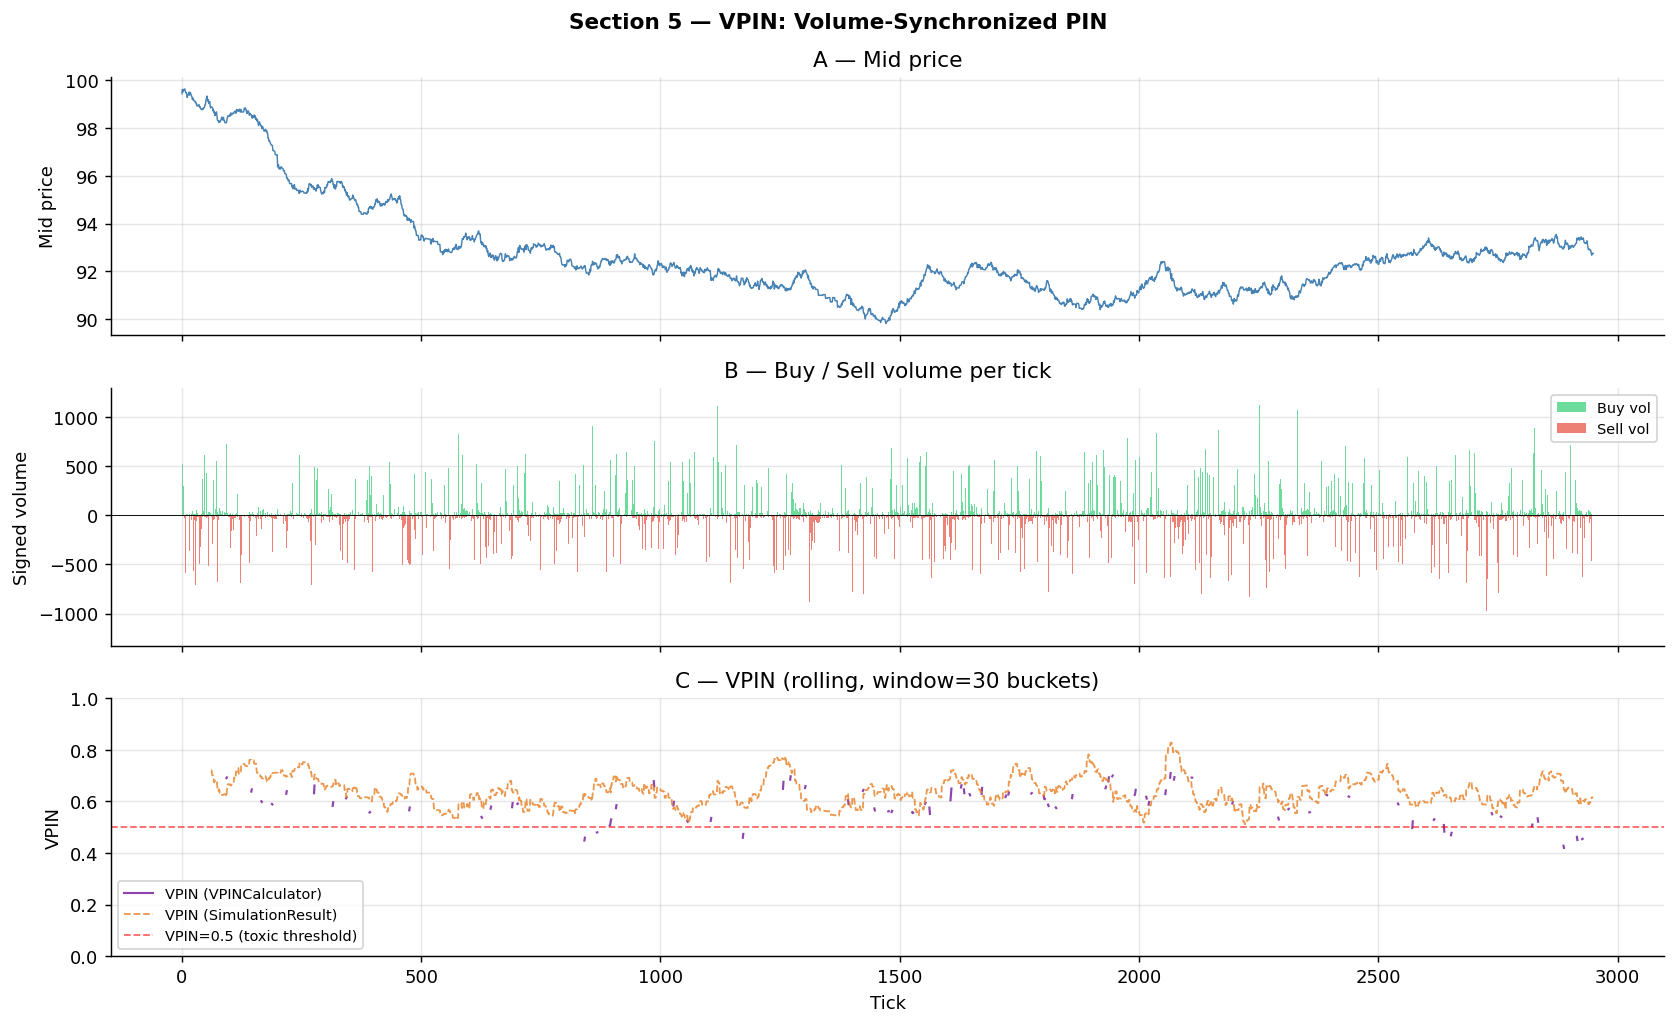

VPIN stats  mean=0.578  std=0.062  max=0.719  p90=0.657
Fraction of ticks with VPIN > 0.5 : 88.0%


In [7]:
vpin_calc   = VPINCalculator(bucket_size=500.0, window=30)
vpin_series = []

for bv, sv in zip(buy_vols, sell_vols):
    v = vpin_calc.update(bv, sv)
    vpin_series.append(v if v is not None else np.nan)

vpin_arr    = np.array(vpin_series)
valid       = ~np.isnan(vpin_arr)
vpin_result = result.vpin_series(window=30)

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

ax = axes[0]
ax.plot(prices, lw=0.8, color="steelblue")
ax.set_ylabel("Mid price"); ax.set_title("A — Mid price")

ax = axes[1]
ax.bar(range(len(buy_vols)),  buy_vols,  color="#2ecc71", alpha=0.7, width=1, label="Buy vol")
ax.bar(range(len(sell_vols)), -sell_vols, color="#e74c3c", alpha=0.7, width=1, label="Sell vol")
ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Signed volume"); ax.set_title("B — Buy / Sell volume per tick")
ax.legend(loc="upper right", fontsize=8)

ax = axes[2]
ax.plot(np.where(valid, vpin_arr, np.nan),
        color="#8e44ad", lw=1.2, label="VPIN (VPINCalculator)")
ax.plot(vpin_result, color="#e67e22", lw=1, ls="--", alpha=0.8,
        label="VPIN (SimulationResult)")
ax.axhline(0.5, ls="--", color="red", lw=1, alpha=0.6, label="VPIN=0.5 (toxic threshold)")
ax.set_ylim(0, 1)
ax.set_ylabel("VPIN"); ax.set_xlabel("Tick")
ax.set_title("C — VPIN (rolling, window=30 buckets)")
ax.legend(fontsize=8)

plt.suptitle("Section 5 — VPIN: Volume-Synchronized PIN", fontweight="bold")
plt.tight_layout()
plt.show()

vpin_valid = vpin_arr[valid]
print(f"VPIN stats  mean={vpin_valid.mean():.3f}  std={vpin_valid.std():.3f}  "
      f"max={vpin_valid.max():.3f}  p90={np.percentile(vpin_valid,90):.3f}")
print(f"Fraction of ticks with VPIN > 0.5 : {(vpin_valid > 0.5).mean():.1%}")

# Section 5 — VPIN (Volume-Synchronized PIN) Analysis

Biểu đồ này minh họa mối quan hệ giữa **price dynamics**, **buy/sell order flow**, và **VPIN** — một thước đo mức độ **toxic order flow** trong thị trường.

VPIN được thiết kế để phát hiện khi **buy volume và sell volume trở nên mất cân bằng mạnh**, điều thường xảy ra khi **informed trading hoặc liquidity stress** xuất hiện.

Trong hình có ba panel chính: **A — Mid price**, **B — Buy/Sell volume**, **C — VPIN**.

---

# A — Mid price

Panel A hiển thị **mid price** của thị trường:

$$
p_t = \frac{P^B_t + P^A_t}{2}
$$

Mid price đại diện cho **giá cân bằng giữa bên mua và bên bán** trong order book.

Quan sát từ biểu đồ:

- Giá bắt đầu khoảng **100**
- Sau đó giảm dần xuống khoảng **90**
- Cuối chuỗi có sự phục hồi nhẹ.

Xu hướng giảm cho thấy trong giai đoạn đầu:

$$
\text{sell pressure} > \text{buy pressure}
$$

Tuy nhiên đường giá tương đối **mượt và liên tục**, không có cú sụt mạnh. Điều này cho thấy thanh khoản trong mô phỏng vẫn khá ổn định và không có sự kiện cực đoan như liquidity shock.

---

# B — Buy / Sell volume per tick

Panel B hiển thị **buy volume và sell volume tại từng tick**.

- cột **xanh lá** biểu thị buy volume
- cột **đỏ** biểu thị sell volume

Nếu:

$$
V^B_t > V^S_t
$$

thì tick đó có **buy pressure**.

Nếu:

$$
V^S_t > V^B_t
$$

thì tick đó có **sell pressure**.

Quan sát cho thấy buy và sell volume **xảy ra xen kẽ khá đều**, với một số spike lớn ở cả hai phía. Điều này nghĩa là thị trường vẫn có hoạt động giao dịch tích cực từ cả buyer và seller, và không có giai đoạn dài mà chỉ một phía hoàn toàn chi phối.

Do đó trong nhiều khoảng thời gian:

$$
V^B_t \approx V^S_t
$$

---

# C — VPIN (rolling window)

Panel C hiển thị **VPIN** được tính trên rolling window **30 volume buckets**.

VPIN đo mức độ **volume imbalance** giữa buy và sell:

$$
\text{VPIN} =
\frac{1}{n}
\sum_{\tau=1}^{n}
\frac{|V^B_\tau - V^S_\tau|}{V_\tau}
$$

Trong đó:

- $V^B_\tau$ là buy volume trong bucket
- $V^S_\tau$ là sell volume
- $V_\tau$ là tổng volume bucket.

Giá trị VPIN nằm trong khoảng:

$$
0 \leq \text{VPIN} \leq 1
$$

Đường đỏ trong biểu đồ biểu thị ngưỡng:

$$
\text{VPIN} = 0.5
$$

thường được xem là **toxic threshold**.

---

# Thống kê VPIN trong simulation

Các thống kê VPIN thu được:

| Metric | Value |
|---|---|
| Mean | 0.578 |
| Std | 0.062 |
| Max | 0.719 |
| 90th percentile | 0.657 |
| Fraction VPIN > 0.5 | 88% |

### Ý nghĩa

Giá trị trung bình:

$$
E[\text{VPIN}] = 0.578
$$

cho thấy phần lớn thời gian **buy và sell volume không cân bằng hoàn toàn**.

Độ lệch chuẩn nhỏ:

$$
\sigma = 0.062
$$

cho thấy mức imbalance này **tương đối ổn định theo thời gian**.

Giá trị lớn nhất:

$$
\max(\text{VPIN}) = 0.719
$$

nghĩa là trong bucket mất cân bằng nhất, một phía chiếm khoảng **85–86% volume**. Tuy nhiên mức này vẫn thấp hơn nhiều so với các giai đoạn khủng hoảng thanh khoản trong dữ liệu thực, nơi VPIN có thể vượt **0.9**.

Giá trị:

$$
P(\text{VPIN} > 0.5) = 88\%
$$

cho thấy phần lớn thời gian order flow có **một phía chiếm ưu thế**, điều thường xảy ra khi trader lớn chia nhỏ lệnh và thực hiện dần theo thời gian.

---

# Liên hệ VPIN với price dynamics

Nếu VPIN thực sự phản ánh **toxic order flow**, ta kỳ vọng:

$$
\text{VPIN}_t \uparrow \Rightarrow \text{price volatility} \uparrow
$$

Tuy nhiên trong simulation:

- VPIN thường nằm trong khoảng **0.55–0.70**
- biến động giá vẫn khá mượt.

Điều này cho thấy **price dynamics trong mô phỏng không được điều khiển trực tiếp bởi order flow toxicity**. Giá có thể đang được sinh từ một **stochastic fundamental process**, trong khi order flow chỉ phản ánh hoạt động giao dịch xung quanh giá đó.

---

# Kết luận

Phân tích VPIN cho thấy:

- Order flow trong simulation thường **mất cân bằng nhẹ nhưng ổn định**.
- VPIN chủ yếu nằm trong vùng:

$$
0.55 \leq \text{VPIN} \leq 0.65
$$

- Không xuất hiện các giai đoạn **extreme toxicity** (VPIN > 0.8).
- Price movement không phản ứng mạnh với VPIN vì mô hình mô phỏng chưa gắn chặt **order flow với price formation**.

Trong dữ liệu thị trường thực, VPIN thường được sử dụng để:

- phát hiện **toxic order flow**
- cảnh báo **liquidity stress**
- hỗ trợ **execution algorithms và market surveillance**.

## 6. Price Impact — Permanent vs Temporary

Một order có hai loại tác động lên giá:

**Permanent impact** $\lambda Q$: phần giá dịch chuyển vĩnh viễn do thông tin. Informed trader mua → fundamental value thực sự cao hơn → market maker update quotes → mid-price tăng permanently.

**Temporary impact** $\eta Q$: friction từ thanh khoản — walk up the book khi sweep multiple levels. Phần này mean-reverts sau khi order được fill.

**Almgren-Chriss linear model:**
$$\Delta P_\text{total} = (\lambda + \eta) \cdot Q \cdot \text{sign}$$

**Calibration từ data:** OLS regression $\Delta p_t = \lambda \cdot \text{SV}_t + \varepsilon_t$ với $\text{SV}_t$ là signed volume. Slope $\hat\lambda$ là ước lượng của Kyle's lambda — đo lường price impact per unit of order flow.

Trong thực tế, impact thường là **concave** (square-root law): $\Delta P \propto \sqrt{Q}$. Model tuyến tính là approximation ở regime volume vừa phải.

# Các khái niệm cần hiểu trước khi đọc biểu đồ Price Impact

Phần này trình bày các lý thuyết nền tảng của **price impact** trong market microstructure.
Price impact nghiên cứu cách **order flow làm thay đổi giá thị trường**.

Mục tiêu là hiểu cơ chế:

$$
\text{Order flow} \rightarrow \text{Price change}
$$

Các mô hình price impact rất quan trọng trong:

- execution algorithms
- optimal trading
- market making
- transaction cost analysis.

---

# 1. Price Impact là gì

**Price impact** là sự thay đổi của giá thị trường gây ra bởi một giao dịch.

Nếu một trader mua một lượng lớn tài sản:

- họ phải khớp với các limit orders trong order book
- điều này làm **mid price tăng**.

Nếu trader bán nhiều:

- họ ăn bid liquidity
- giá giảm.

Do đó:

$$
\Delta P \propto Q
$$

Trong đó:

- $Q$ : khối lượng order
- $\Delta P$ : thay đổi giá.

---

# 2. Order Book Mechanics

Price impact xuất phát từ cấu trúc của **limit order book**.

Ví dụ order book:

| Price | Volume |
|---|---|
| 100 | 50 |
| 101 | 80 |
| 102 | 100 |

Nếu trader gửi:


market buy = 120


Thì order sẽ:

- ăn 50 tại 100
- ăn 70 tại 101

Mid price sau trade sẽ tăng.

Hiện tượng này gọi là:

> **walking the book**

---

# 3. Permanent Price Impact

Permanent impact là phần **dịch chuyển vĩnh viễn của giá**.

Ký hiệu:

$$
\lambda Q
$$

Trong đó:

- $\lambda$ : price impact coefficient
- $Q$ : order size.

Permanent impact xảy ra khi thị trường tin rằng order chứa **thông tin về giá trị tài sản**.

Ví dụ:

informed trader mua lớn vì biết:

$$
V > P_t
$$

Market makers nhận ra tín hiệu này và điều chỉnh quote.

Giá mới:

$$
P_{t+1} = P_t + \lambda Q
$$

Phần dịch chuyển này **không quay lại**.

---

# 4. Temporary Price Impact

Temporary impact là phần tác động **tạm thời do thanh khoản hạn chế**.

Ký hiệu:

$$
\eta Q
$$

Temporary impact xảy ra khi:

- trader sweep nhiều mức giá
- order book tạm thời bị rỗng.

Sau khi trade kết thúc:

- liquidity providers đặt lại limit orders
- giá quay về gần mức trước.

Do đó temporary impact **mean-reverts**.

---

# 5. Tổng Price Impact

Trong nhiều mô hình, tổng impact được tách thành:

- permanent component
- temporary component.

Theo **Almgren–Chriss model**:

$$
\Delta P_{total} = (\lambda + \eta) Q \cdot \text{sign}
$$

Trong đó:

- $\lambda$ : permanent impact
- $\eta$ : temporary impact
- sign : hướng giao dịch.

---

# 6. Kyle’s Lambda

Một thước đo quan trọng của price impact là **Kyle’s lambda**.

Kyle (1985) mô hình hóa price formation trong thị trường có informed trader.

Trong equilibrium:

$$
\Delta p_t = \lambda \cdot q_t
$$

Trong đó:

- $q_t$ : signed order flow
- $\lambda$ : price sensitivity.

Lambda đo:

> **mức độ giá phản ứng với order flow**.

Nếu $\lambda$ lớn:

- thị trường **illiquid**
- order nhỏ cũng làm giá thay đổi mạnh.

Nếu $\lambda$ nhỏ:

- thị trường **deep liquidity**
- price impact thấp.

---

# 7. Calibration từ dữ liệu

Trong dữ liệu thực, $\lambda$ thường được ước lượng bằng regression:

$$
\Delta p_t = \lambda \cdot SV_t + \varepsilon_t
$$

Trong đó:

$$
SV_t = s_t v_t
$$

là **signed volume**.

Hệ số slope của regression:

$$
\hat{\lambda}
$$

là ước lượng của **Kyle's lambda**.

---

# 8. Concave Impact — Square Root Law

Trong thực tế price impact không hoàn toàn tuyến tính.

Nhiều nghiên cứu thực nghiệm cho thấy:

$$
\Delta P \propto \sqrt{Q}
$$

gọi là **square-root impact law**.

Điều này nghĩa là:

- order lớn hơn tạo impact lớn hơn
- nhưng **không tăng tuyến tính**.

Ví dụ:

| Order size | Impact |
|---|---|
| 1x | 1 |
| 4x | 2 |

Impact tăng theo:

$$
\sqrt{Q}
$$

chứ không phải $Q$.

---

# 9. Execution Cost và Implementation Shortfall

Price impact là thành phần chính của **transaction cost**.

Một trader muốn mua $Q$ cổ phiếu tại giá ban đầu $P_0$.

Giá thực tế khi khớp:

$$
P_{exec} > P_0
$$

Chi phí thực hiện gọi là **implementation shortfall**:

$$
IS = \sum (P_{exec} - P_0) Q
$$

Execution algorithms cố gắng giảm chi phí này bằng cách:

- chia order thành nhiều phần
- giao dịch dần theo thời gian.

---

# 10. Order Splitting

Do impact tăng theo size, trader thường:


large order
→ split into small trades


Ví dụ:


- Buy 1000 shares


thay vì một trade, họ thực hiện:


- 10 trades × 100 shares


Điều này giảm:

- temporary impact
- market footprint.

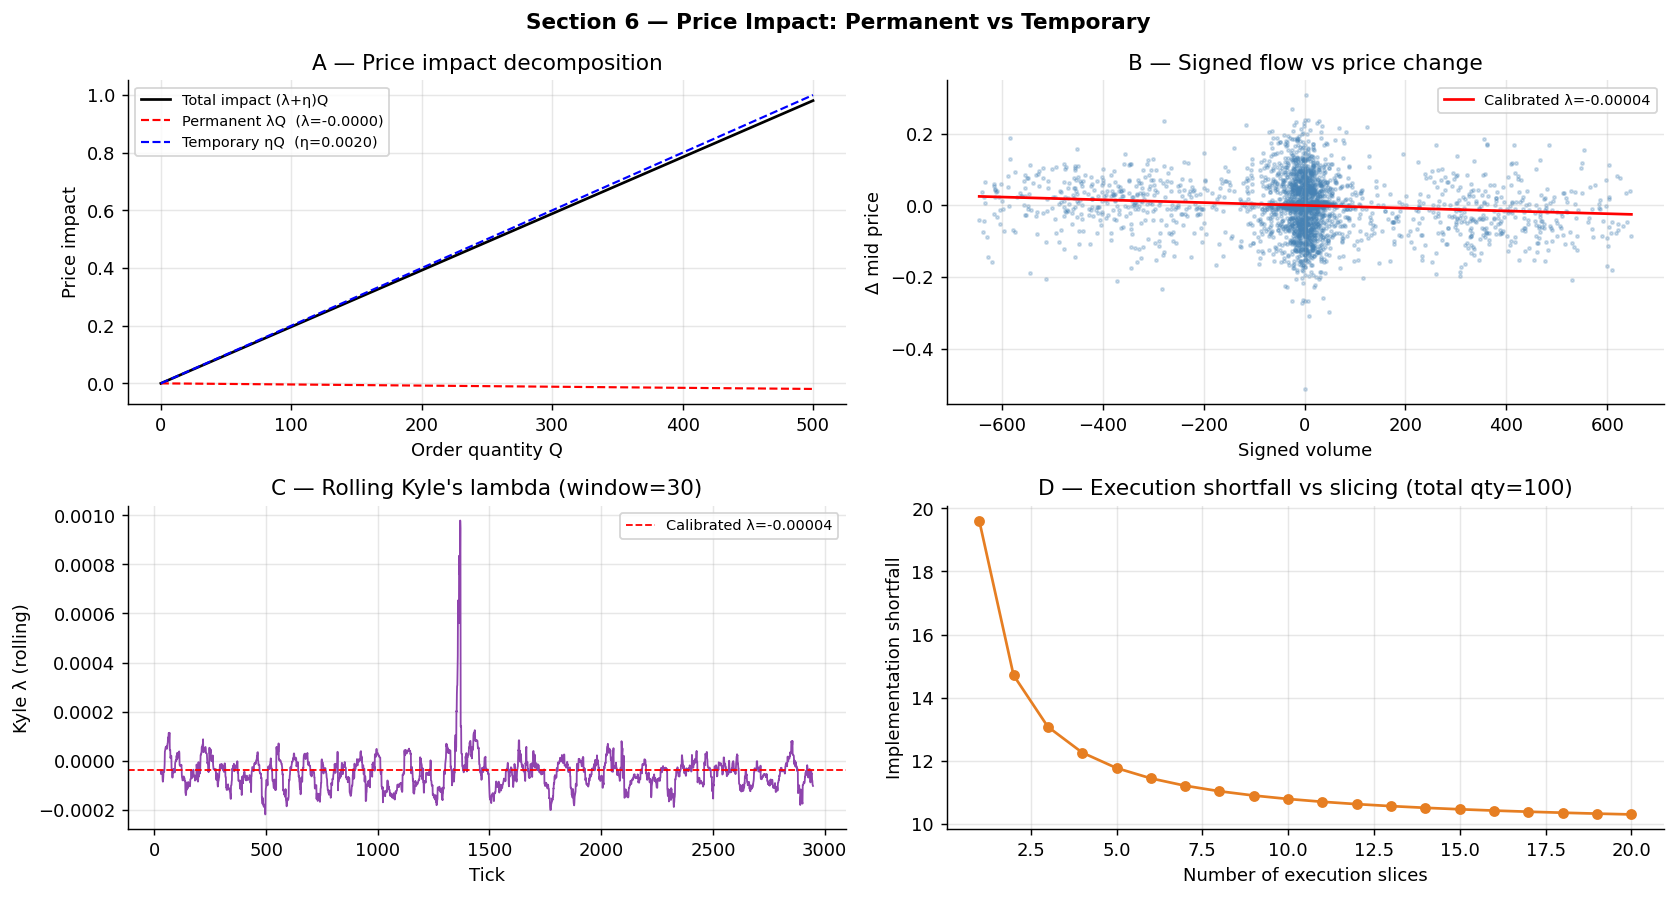

Calibrated Kyle λ  = -0.000039
Temporary impact η = 0.002000
Impact ratio perm/total = -2.0%


In [8]:
model = PriceImpactModel(lambda_=0.001, eta=0.002)

sv    = result.signed_volume()
dp    = np.diff(prices)
n_fit = min(len(sv), len(dp))
model.calibrate(sv[:n_fit], dp[:n_fit])

qty_range = np.linspace(0, 500, 200)
total_imp = [model.total_impact(q, sign=1)     for q in qty_range]
perm_imp  = [model.permanent_impact(q, sign=1) for q in qty_range]
temp_imp  = [model.temporary_impact(q, sign=1) for q in qty_range]

kyle_series = result.kyle_lambda_series(window=30)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))

ax = axes[0, 0]
ax.plot(qty_range, total_imp, "k-",  lw=1.5, label="Total impact (λ+η)Q")
ax.plot(qty_range, perm_imp,  "r--", lw=1.2, label=f"Permanent λQ  (λ={model.lambda_:.4f})")
ax.plot(qty_range, temp_imp,  "b--", lw=1.2, label=f"Temporary ηQ  (η={model.eta:.4f})")
ax.set_xlabel("Order quantity Q"); ax.set_ylabel("Price impact")
ax.set_title("A — Price impact decomposition"); ax.legend(fontsize=8)

ax   = axes[0, 1]
clip = np.percentile(np.abs(sv[:n_fit]), 97)
mask = np.abs(sv[:n_fit]) < clip
ax.scatter(sv[:n_fit][mask], dp[:n_fit][mask], s=3, alpha=0.25, color="steelblue")
q_line = np.linspace(sv[:n_fit][mask].min(), sv[:n_fit][mask].max(), 100)
ax.plot(q_line, model.lambda_ * q_line, "r-", lw=1.5,
        label=f"Calibrated λ={model.lambda_:.5f}")
ax.set_xlabel("Signed volume"); ax.set_ylabel("Δ mid price")
ax.set_title("B — Signed flow vs price change"); ax.legend(fontsize=8)

ax = axes[1, 0]
ax.plot(kyle_series, lw=1, color="#8e44ad")
ax.axhline(model.lambda_, ls="--", color="red", lw=1,
           label=f"Calibrated λ={model.lambda_:.5f}")
ax.set_xlabel("Tick"); ax.set_ylabel("Kyle λ (rolling)")
ax.set_title("C — Rolling Kyle's lambda (window=30)"); ax.legend(fontsize=8)

ax = axes[1, 1]
base_qty = 100.0
shortfalls = []
for urgency in range(1, 21):
    q_s = np.full(urgency, base_qty / urgency)
    s_s = np.ones(urgency)
    shortfalls.append(model.execution_shortfall(q_s, s_s, arrival_price=prices[0]))
ax.plot(range(1, 21), shortfalls, "o-", color="#e67e22", ms=5)
ax.set_xlabel("Number of execution slices"); ax.set_ylabel("Implementation shortfall")
ax.set_title(f"D — Execution shortfall vs slicing (total qty={base_qty:.0f})")

plt.suptitle("Section 6 — Price Impact: Permanent vs Temporary", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Calibrated Kyle λ  = {model.lambda_:.6f}")
print(f"Temporary impact η = {model.eta:.6f}")
print(f"Impact ratio perm/total = {model.lambda_/(model.lambda_+model.eta):.1%}")

# Section 6 — Price Impact: Permanent vs Temporary

Phần này nghiên cứu **price impact** — tức là **giá thay đổi như thế nào khi có giao dịch xảy ra**.

Ý tưởng cơ bản của microstructure:

$$
\text{Order flow} \rightarrow \text{Price change}
$$

Khi có một trader mua hoặc bán một lượng lớn tài sản, giá thường sẽ thay đổi.
Nhưng sự thay đổi đó có **hai loại khác nhau**:

- **Permanent impact** – thay đổi vĩnh viễn
- **Temporary impact** – thay đổi tạm thời

Biểu đồ minh họa hai loại tác động này và cách chúng được ước lượng từ dữ liệu.

---

# 1. Permanent vs Temporary impact

## Permanent impact

Permanent impact là phần **giá thay đổi vĩnh viễn** sau khi giao dịch.

Nguyên nhân:

- thị trường cho rằng giao dịch chứa **thông tin**.

Ví dụ:

Một trader mua rất nhiều cổ phiếu.

Market maker nghĩ rằng trader đó có thể biết:

$$
\text{giá trị thật của tài sản} > \text{giá hiện tại}
$$

Do đó họ **điều chỉnh giá lên**.

Phần tăng này **không quay lại**.

Công thức:

$$
\Delta P_{\text{perm}} = \lambda Q
$$

Trong đó

- $Q$ : khối lượng lệnh
- $\lambda$ : độ nhạy của giá với order flow (Kyle’s lambda)

---

## Temporary impact

Temporary impact là phần thay đổi **tạm thời**.

Nguyên nhân:

- thanh khoản trong order book bị ăn hết tạm thời.

Ví dụ order book:

| Price | Volume |
|---|---|
| 100 | 50 |
| 101 | 60 |
| 102 | 80 |

Nếu trader mua:


120 shares


Lệnh sẽ:

- ăn 50 tại 100
- ăn 60 tại 101
- ăn 10 tại 102

Giá khớp trung bình cao hơn → **giá tăng tạm thời**.

Sau khi lệnh kết thúc:

- market maker đặt thêm limit orders
- order book đầy lại

Giá **có thể quay xuống**.

Temporary impact:

$$
\Delta P_{\text{temp}} = \eta Q
$$

---

## Tổng impact

Hai phần cộng lại:

$$
\Delta P_{\text{total}} = (\lambda + \eta) Q
$$

---

# 2. Panel A — Price impact decomposition

Biểu đồ A thể hiện **price impact theo kích thước lệnh $Q$**.

### Trục

- **trục x**: kích thước lệnh $Q$
- **trục y**: price impact

### Các đường

3 đường được vẽ:

- **đường đen** – tổng impact
- **đường đỏ** – permanent impact
- **đường xanh** – temporary impact

### Cách đọc

Khi $Q$ tăng:

- price impact tăng
- vì lệnh lớn ăn nhiều thanh khoản hơn.

### Điều quan trọng trong biểu đồ

Đường permanent impact gần như **nằm sát trục 0**.

Lý do:

$$
\lambda = -0.000039
$$

rất nhỏ so với

$$
\eta = 0.002
$$

Điều này nghĩa là:

> trong simulation, price change gần như **không đến từ thông tin**, mà chỉ do **liquidity friction**.

---

# 3. Panel B — Signed flow vs price change

Biểu đồ B là **scatter plot**.

Nó kiểm tra mối quan hệ giữa:

- **signed volume**
- **price change**

## Khái niệm signed volume

Signed volume:

$$
SV_t = s_t v_t
$$

Trong đó

- $v_t$ : volume giao dịch
- $s_t$ : trade sign

Trade sign:

- buy → $+1$
- sell → $-1$

Ví dụ

| trade | volume | signed volume |
|---|---|---|
| buy | 100 | +100 |
| sell | 80 | −80 |

---

## Trục của biểu đồ

- **x-axis**: signed volume
- **y-axis**: thay đổi giá $\Delta p$

Mỗi điểm là **một giao dịch**.

---

## Logic của biểu đồ

Nếu order flow thực sự làm giá thay đổi, ta kỳ vọng:

- buy volume lớn → giá tăng
- sell volume lớn → giá giảm

Nghĩa là:

$$
SV_t > 0 \Rightarrow \Delta p_t > 0
$$

$$
SV_t < 0 \Rightarrow \Delta p_t < 0
$$

Khi đó scatter plot sẽ tạo thành **đường nghiêng lên**.

---

## Quan sát

Trong biểu đồ:

- các điểm phân tán khá ngẫu nhiên
- slope gần như bằng 0.

Điều này nghĩa là:

$$
\text{Corr}(SV_t,\Delta p_t) \approx 0
$$

Signed volume **không giải thích được price change**.

---

# 4. Panel C — Rolling Kyle's lambda

Biểu đồ C cho thấy **Kyle’s lambda theo thời gian**.

## Khái niệm Kyle’s lambda

Kyle’s lambda đo:

> giá nhạy với order flow như thế nào.

Mô hình:

$$
\Delta p_t = \lambda SV_t + \varepsilon_t
$$

Nếu

- $\lambda$ lớn → thị trường illiquid
- $\lambda$ nhỏ → thị trường deep liquidity

---

## Trục biểu đồ

- **x-axis**: tick (thời gian)
- **y-axis**: $\lambda$ được tính bằng rolling regression.

---

## Quan sát

Đường tím dao động quanh 0.

Điều này nghĩa là:

- order flow **không làm giá thay đổi mạnh**
- price dynamics gần như **độc lập với order flow**.

---

# 5. Panel D — Execution shortfall vs slicing

Biểu đồ D mô phỏng **chi phí thực hiện giao dịch**.

## Khái niệm execution shortfall

Execution shortfall là chi phí do:

- price impact
- slippage.

Công thức:

$$
IS = \sum (P_{\text{exec}} - P_0) q_i
$$

Trong đó

- $P_{\text{exec}}$ : giá khớp
- $P_0$ : giá ban đầu.

---

## Trục biểu đồ

- **x-axis**: số lần chia nhỏ lệnh
- **y-axis**: execution shortfall.

---

## Logic của biểu đồ

Giả sử trader muốn mua:


100 shares


Có hai cách:

### cách 1


1 trade × 100


impact lớn.

### cách 2


10 trades × 10


impact nhỏ hơn.

---

## Quan sát

Biểu đồ cho thấy:

- khi tăng số slice từ 1 → 5
  execution cost giảm mạnh

- sau đó giảm chậm.

Điều này phản ánh nguyên lý:

> **order splitting giúp giảm market impact**.

---

# Kết luận

Các biểu đồ cho thấy:

1. Price impact trong simulation chủ yếu là

$$
\text{temporary impact}
$$

2. Permanent impact gần như bằng 0:

$$
\lambda \approx 0
$$

3. Order flow không mang nhiều thông tin về giá trị tài sản.

4. Chia nhỏ lệnh giúp giảm execution cost do giảm temporary impact.

Những đặc điểm này thường xuất hiện trong **simple market simulations**, nơi price được sinh từ một **stochastic process độc lập với order flow**.

## 7. Informed vs Noise Trader Flow

**Glosten-Milgrom (1985)** framework: thị trường gồm hai loại trader:

- **Noise trader** (uninformed): giao dịch vì thanh khoản, hedging, hoặc noise. Direction iid random, không liên quan fundamental.
- **Informed trader**: có private signal về $v$ (true value). Giao dịch theo hướng tối đa hóa profit từ thông tin: mua nếu $v > \text{ask}$, bán nếu $v < \text{bid}$.

Market maker không quan sát được trader type, chỉ quan sát order. Expected loss cho MM khi giao dịch với informed trader là **adverse selection cost** — phần chính trong bid-ask spread.

**PIN** ước lượng $\alpha$ (fraction của arriving orders là informed) từ asymmetry giữa buy và sell arrival rates trong ngày có tin tức.

Trong simulation, ta kiểm soát trực tiếp `prob_informed` và `signal_strength`, cho phép:
- So sánh OFI, VPIN, và Kyle λ theo mức độ informed trading
- Quan sát price discovery speed: giá converge về fundamental nhanh hơn khi có nhiều informed trader
- Đo lường adverse selection cost của market maker

# 1. Hai loại trader trong microstructure

Theo mô hình Glosten–Milgrom, thị trường có hai loại trader.

## Noise trader (uninformed)

Noise trader là trader **không có thông tin về giá trị thật của tài sản**.

Họ giao dịch vì nhiều lý do:

- nhu cầu thanh khoản
- hedging
- portfolio rebalancing
- hoặc đơn giản là giao dịch ngẫu nhiên.

Do đó direction của giao dịch gần như **random**.

Ví dụ:

| Trader | Decision |
|---|---|
| A | buy |
| B | sell |
| C | buy |
| D | sell |

Direction gần như **iid random**.

Điều này có nghĩa:

$$
E[\text{signed order flow}] \approx 0
$$

Noise trader **không làm thay đổi giá trị fundamental của tài sản**.

---

## Informed trader

Informed trader có **private information** về giá trị thật của tài sản.

Ký hiệu:

$$
v
$$

là **true value** của tài sản.

Informed trader quan sát một **signal** về $v$.

Họ giao dịch theo quy tắc:

- nếu

$$
v > \text{ask}
$$

→ mua

- nếu

$$
v < \text{bid}
$$

→ bán

Vì vậy order flow của informed trader **không ngẫu nhiên**.

Nó có **directional bias**.

---

# 2. Market maker và adverse selection

Market maker đặt:

| Bid | Ask |
|---|---|
| 99 | 100 |

Khi một trader gửi lệnh:


market buy


Market maker **không biết trader đó là noise hay informed**.

Nếu trader là informed và biết:

$$
v = 105
$$

thì market maker bán tại 100 và sau đó giá tăng.

Market maker bị lỗ.

Khoản lỗ này gọi là:

> **adverse selection cost**

---

# 3. Bid–ask spread và informed trading

Bid–ask spread có nhiều thành phần:

$$
\text{Spread} =
\text{order processing cost}
+
\text{inventory risk}
+
\text{adverse selection cost}
$$

Trong đó **adverse selection** xuất phát từ informed traders.

Nếu thị trường có nhiều informed traders:

- spread phải rộng hơn
- market maker cần bảo vệ mình.

---

# 4. Price discovery

Price discovery là quá trình **giá thị trường dần phản ánh giá trị thật**.

Giả sử giá trị thật:

$$
v = 105
$$

Nhưng giá ban đầu:


price = 100


Nếu informed trader mua liên tục:


buy
buy
buy
buy


Market maker nhận ra tín hiệu và điều chỉnh giá.

Giá dần tiến tới:

$$
p \rightarrow v
$$

Quá trình này gọi là **price discovery**.

---

# 5. PIN — Probability of Informed Trading

PIN đo xác suất rằng một order đến từ informed trader.

Ký hiệu:

$$
\alpha
$$

là fraction của informed traders.

Nếu:

$$
\alpha \uparrow
$$

thì:

- order flow có bias mạnh hơn
- giá phản ánh thông tin nhanh hơn.

PIN được ước lượng từ **sự bất đối xứng giữa buy và sell arrival rates**.

---

# 6. Simulation setup

Trong simulation, informed trading được điều khiển bằng hai tham số.

### prob_informed

Xác suất một order đến từ informed trader.

Ví dụ:

| Scenario | prob_informed |
|---|---|
| Low | 0.05 |
| Medium | 0.20 |
| High | 0.40 |

---

### signal_strength

Độ mạnh của signal về giá trị thật.

Nếu signal_strength cao:

- informed trader gần như luôn giao dịch đúng direction.

---

# 7. Các đại lượng được đo

Trong mỗi scenario ta đo:

### số lượng trader

- $n_{\text{informed}}$
- $n_{\text{noise}}$

---

### signed volume

Signed volume của informed trader:

$$
SV_{\text{inf}} = \sum s_t v_t
$$

Signed volume của noise trader:

$$
SV_{\text{noise}} = \sum s_t v_t
$$

---

# 8. Điều ta kỳ vọng thấy trong biểu đồ

Khi tăng tỷ lệ informed trader:

### order flow

Informed flow sẽ **có bias rõ rệt**.

Noise flow vẫn gần random.

---

### price discovery

Giá sẽ converge nhanh hơn về:

$$
v
$$

---

### market maker risk

Adverse selection cost sẽ tăng vì:

- market maker thường giao dịch với informed trader.

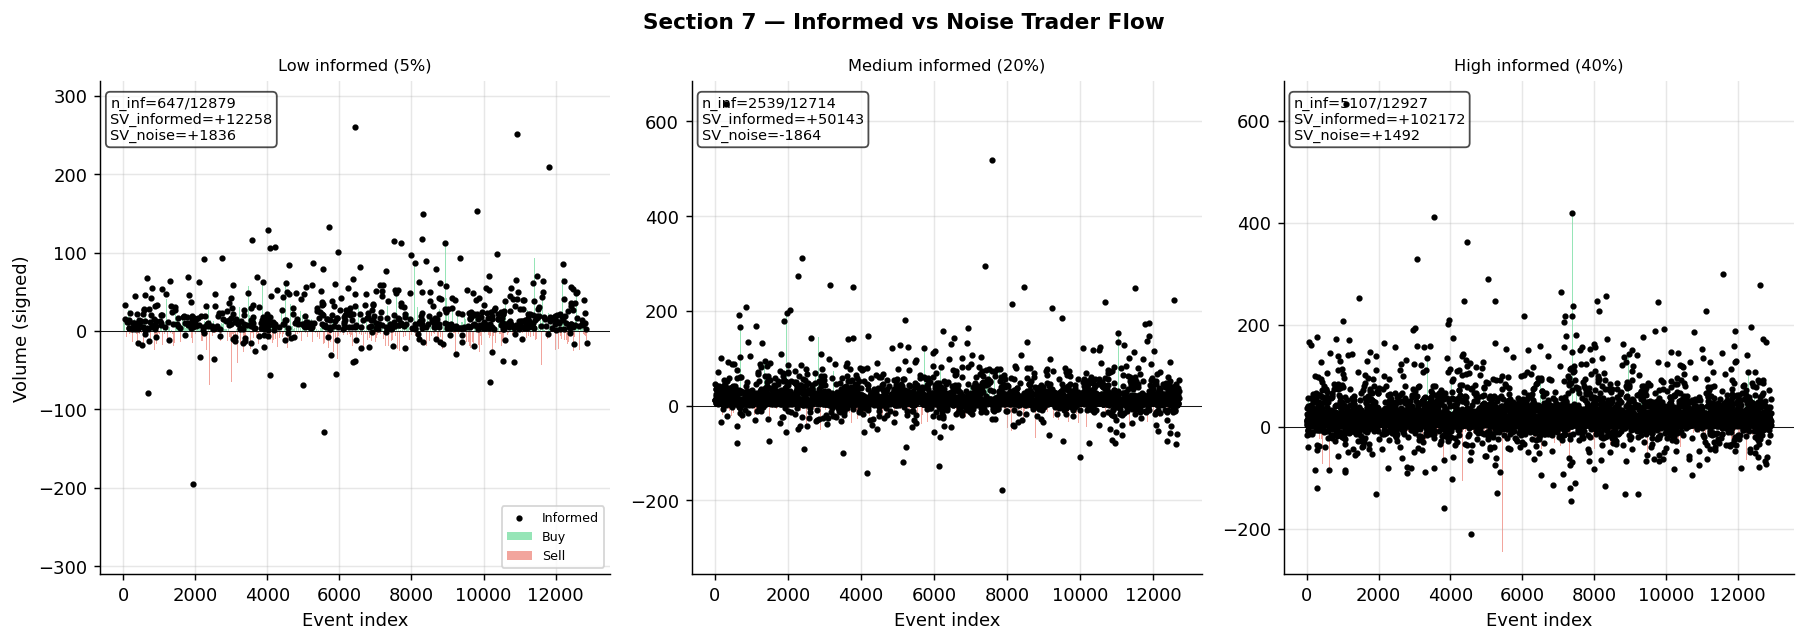


Scenario                      n_inf  n_noise  SV_informed   SV_noise
--------------------------------------------------------------------
Low informed (5%)               647    12232     +12257.5    +1836.1
Medium informed (20%)          2539    10175     +50142.9    -1863.8
High informed (40%)            5107     7820    +102171.8    +1491.8


In [9]:
scenarios = {
    "Low informed (5%)":     dict(prob_informed=0.05, n_steps=800, seed=10),
    "Medium informed (20%)": dict(prob_informed=0.20, n_steps=800, seed=11),
    "High informed (40%)":   dict(prob_informed=0.40, n_steps=800, seed=12),
}

results_inf = {}
for label, cfg in scenarios.items():
    rng_s    = np.random.default_rng(cfg["seed"])
    arrival  = PoissonArrivalProcess(lambda_buy=8.0, lambda_sell=8.0,
                                     dt=1.0, rng=rng_s)
    size_dist = OrderSizeDistribution(rng=np.random.default_rng(cfg["seed"]))
    gen = OrderFlowGenerator(
        prob_informed=cfg["prob_informed"],
        signal_strength=0.80,
        arrival_process=arrival,
        size_dist=size_dist,
        rng=np.random.default_rng(cfg["seed"]),
    )
    gen.update_signal(signal=1)
    events = gen.generate(cfg["n_steps"], mid_price=100.0)

    noise_events    = [e for e in events if e.trader_type == TraderType.NOISE]
    informed_events = [e for e in events if e.trader_type == TraderType.INFORMED]
    noise_sv    = sum(e.quantity if e.side=="bid" else -e.quantity for e in noise_events)
    informed_sv = sum(e.quantity if e.side=="bid" else -e.quantity for e in informed_events)

    results_inf[label] = dict(
        events=events,
        noise_sv=noise_sv, informed_sv=informed_sv,
        n_noise=len(noise_events), n_informed=len(informed_events),
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ["#3498db", "#e67e22", "#e74c3c"]

for ax, (label, res), color in zip(axes, results_inf.items(), colors):
    events  = res["events"]
    bid_vol = np.array([e.quantity if e.side == "bid" else 0 for e in events])
    ask_vol = np.array([e.quantity if e.side == "ask" else 0 for e in events])
    informed = np.array([1 if e.trader_type == TraderType.INFORMED else 0
                         for e in events])

    ax.bar(range(len(bid_vol)),  bid_vol, color="#2ecc71", alpha=0.5, width=1, label="Buy")
    ax.bar(range(len(ask_vol)), -ask_vol, color="#e74c3c", alpha=0.5, width=1, label="Sell")
    inf_idx  = np.where(informed)[0]
    inf_side = np.array([bid_vol[i] if events[i].side=="bid" else -ask_vol[i]
                         for i in inf_idx])
    ax.scatter(inf_idx, inf_side, s=6, color="black", zorder=5, label="Informed")
    ax.axhline(0, color="black", lw=0.5)
    ax.set_title(label, fontsize=9); ax.set_xlabel("Event index")
    if ax == axes[0]:
        ax.set_ylabel("Volume (signed)")
        ax.legend(fontsize=7, loc="lower right")

    n_inf = res["n_informed"]; n_tot = len(events)
    ax.text(0.02, 0.97,
            f"n_inf={n_inf}/{n_tot}\n"
            f"SV_informed={res['informed_sv']:+.0f}\n"
            f"SV_noise={res['noise_sv']:+.0f}",
            transform=ax.transAxes, va="top", fontsize=8,
            bbox=dict(boxstyle="round", fc="white", alpha=0.7))

plt.suptitle("Section 7 — Informed vs Noise Trader Flow", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"\n{'Scenario':<28} {'n_inf':>6} {'n_noise':>8} {'SV_informed':>12} {'SV_noise':>10}")
print("-" * 68)
for label, res in results_inf.items():
    print(f"{label:<28} {res['n_informed']:>6} {res['n_noise']:>8} "
          f"{res['informed_sv']:>+12.1f} {res['noise_sv']:>+10.1f}")

# Section 7 — Informed vs Noise Trader Flow (Phân tích biểu đồ)

Biểu đồ này minh họa **dòng lệnh (order flow)** khi thị trường có tỷ lệ **informed trader khác nhau**.
Ba kịch bản được mô phỏng:

| Scenario | Tỷ lệ informed trader |
|---|---|
| Low informed | 5% |
| Medium informed | 20% |
| High informed | 40% |

Mục tiêu là quan sát:

$$
\text{Trader type} \rightarrow \text{Order flow structure}
$$

và hiểu cách **informed traders tạo bias trong order flow**.

---

# Cách đọc biểu đồ

Mỗi panel có cấu trúc giống nhau.

### Trục

- **x-axis:** event index
  → thứ tự các giao dịch xảy ra trong simulation

- **y-axis:** signed volume

Signed volume được định nghĩa:

$$
SV_t = s_t \cdot v_t
$$

trong đó

- $v_t$ = volume giao dịch
- $s_t$ = trade sign

Trade sign:

- buy → $+1$
- sell → $-1$

Do đó:

- giá trị **dương** → buy order
- giá trị **âm** → sell order

---

### Các thành phần trong biểu đồ

Biểu đồ có ba lớp dữ liệu:

1. **Cột xanh lá** → buy volume
2. **Cột đỏ** → sell volume
3. **Chấm đen** → giao dịch từ informed trader

Nhờ vậy ta có thể nhìn thấy:

- tổng order flow
- vị trí của informed traders.

---

# Panel 1 — Low informed (5%)

### Thống kê

| Metric | Value |
|---|---|
| Informed traders | 647 |
| Noise traders | 12232 |
| Signed volume informed | +12257 |
| Signed volume noise | +1836 |

### Quan sát từ biểu đồ

Các chấm đen (informed trader):

- xuất hiện khá **thưa**
- phần lớn giao dịch là noise.

Signed volume dao động quanh 0.

Điều này nghĩa là:

$$
E[SV] \approx 0
$$

Order flow gần như **random**.

### Ý nghĩa

Trong thị trường có ít informed trader:

- price discovery chậm
- order flow không có direction rõ ràng.

Market maker khó nhận ra thông tin từ giao dịch.

---

# Panel 2 — Medium informed (20%)

### Thống kê

| Metric | Value |
|---|---|
| Informed traders | 2539 |
| Noise traders | 10175 |
| Signed volume informed | +50143 |
| Signed volume noise | -1864 |

### Quan sát

Các chấm đen xuất hiện **nhiều hơn đáng kể**.

Signed volume từ informed trader có **bias dương lớn**.

Điều này có nghĩa:

$$
SV_{\text{informed}} \gg 0
$$

Tức là informed traders **mua nhiều hơn bán**.

### Ý nghĩa

Khi informed traders chiếm tỷ lệ lớn hơn:

- order flow bắt đầu có **directional signal**
- market maker có thể suy ra rằng giá trị thật cao hơn.

Điều này thúc đẩy **price discovery**.

---

# Panel 3 — High informed (40%)

### Thống kê

| Metric | Value |
|---|---|
| Informed traders | 5107 |
| Noise traders | 7820 |
| Signed volume informed | +102172 |
| Signed volume noise | +1492 |

### Quan sát

Các chấm đen rất dày.

Signed volume của informed trader tăng mạnh:

$$
SV_{\text{informed}} \approx 10^5
$$

Điều này tạo **bias mạnh trong order flow**.

### Ý nghĩa

Trong trường hợp này:

- phần lớn order flow chứa thông tin
- giá sẽ nhanh chóng điều chỉnh.

Price discovery diễn ra **rất nhanh**.

---

# So sánh ba kịch bản

| Scenario | Order flow structure | Price discovery |
|---|---|---|
| 5% informed | gần random | chậm |
| 20% informed | có bias nhẹ | trung bình |
| 40% informed | bias mạnh | nhanh |

Điểm quan trọng:

Noise trader flow có:

$$
E[SV_{\text{noise}}] \approx 0
$$

nhưng informed trader flow có:

$$
E[SV_{\text{inf}}] \neq 0
$$

Chính sự **không cân bằng này** là nguồn gốc của:

- price impact
- price discovery.

---

# Insight quan trọng

Biểu đồ cho thấy một nguyên lý cơ bản của market microstructure:

> **Giá không phản ánh thông tin ngay lập tức.
Thông tin được truyền vào giá thông qua order flow.**

Khi số lượng informed traders tăng:

1. order flow trở nên **có direction**
2. market maker nhận ra tín hiệu
3. giá điều chỉnh nhanh hơn.

---

# Kết luận

Biểu đồ minh họa cách **informed trading tạo ra bias trong order flow**.

Khi tỷ lệ informed trader tăng:

- signed volume của informed trader tăng mạnh
- order flow mất cân bằng
- price discovery diễn ra nhanh hơn.

Noise traders đóng vai trò **tạo thanh khoản**, nhưng không đóng góp vào quá trình truyền thông tin vào giá.

## Tổng kết

| Metric | Đo lường | Notebook tiếp theo |
|---|---|---|
| Hawkes branching ratio $\rho = \alpha/\beta$ | Mức độ clustering của order flow | `07_structural_fragility` |
| OFI | Net queue pressure tại best bid/ask | `03_price_formation` |
| VPIN | Fraction volume từ informed → toxicity | `02_liquidity_and_depth` (spread) |
| Kyle λ | Price impact per unit signed flow | `03_price_formation`, `04_market_maker` |
| Informed fraction | Adverse selection exposure của MM | `04_market_maker_inventory` |

**Key insight:** Ba metrics — OFI, VPIN, Kyle λ — đều phản ánh cùng một hiện tượng từ góc độ khác nhau: sự hiện diện của thông tin trong order flow. Khi informed trading tăng, cả ba đồng thời tăng, và market maker bị buộc phải mở rộng spread để bù đắp adverse selection cost (Notebook 02).